<img src="../code/Resources/cropped-SummerWorkshop_Header.png"> 

<h1 align="center">Workshop 2: Tutorial on neuronal decoding and behavior</h1> 
<h3 align="center">Summer Workshop on the Dynamic Brain</h3> 
<h3 align="center">Thursday, August 26th, 2025</h3> 
<h4 align="center">Day 2</h4>

# 0.0 Neural Coding 

Neural coding describes how neurons represent information about the world. Coding can be studied by asking whether external or internal events lead to changes in neural activity (**encoding**), or by asking whether different types of information can be read out from neural activity (**decoding**). In this workshop we will focus on this later problem. Specifically, we will try to read out information about stiumus identity from neurons recorded during the Dynamic Routing Task.

### 0.1 The dynamic routing task

Recall the task from before lunch. There are four stimuli, two visual (vis1, vis2) and two auditory (sound1, sound2), plus catch trials with no stimulus.

The trick is **context**. The session alternates between visual and auditory blocks. 
- In a visual block -> only vis1 (the visual target) is rewarded.
- In an auditory block -> only sound1 (the auditory target) is rewarded.

i.e., the same stimulus can be a target or not, depending on which context the mouse is in. 

### 0.2 Our questions

1. Can we tell which stimulus the mouse got, just from spikes?
2. Does the whole population do better than one neuron?
3. When the decoder is wrong, why is it wrong?



# 1.0 Setup

To Python, we first need packages Lets start with some you are familiar with. Numpy, Pandas, and matplotlib should be favorites of yours by now. In addition, lets grab your new friend pynwb so that we can actually look some data!

First the imports. We add seaborn and set the talk context so fonts are readable on a projector.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# pynwb reads the Neuropixels session file (NWB format)
import pynwb

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

sns.set_context('talk')          # readable on a projector
pd.set_option('display.max_columns', None)

### Meet scikit-learn

*Did you notice the sklearn imports at the top? scikit-learn is Python's standard machine-learning library, it gives us the SVM, the train/test split, and cross-validation with one consistent interface.*
### 1.1 An example session.

We will all use the same one to get started.

In [2]:
# ---- load one session from the Code Ocean capsule ----
import glob

session_id = '759434_2025-02-04'

# the capsule stores each session as a .nwb.zarr folder; glob finds it so we
# never hardcode the parent directory
data_root = '/root/capsule/data/dynamicrouting_datacube'
match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
assert len(match_list) == 1, \
    'expected exactly one match for session %s, found %d' % (session_id, len(match_list))
nwb_path = match_list[0]
print('loading session from: %s' % nwb_path)

session = pynwb.read_nwb(nwb_path)
print('loaded session %s' % session_id)

loading session from: /root/capsule/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


loaded session 759434_2025-02-04


Take a look at the whole session object. Click the triangles to explore what is inside.

In [3]:
session

,timestamps
id,
0,NaN
1,14.42651
2,14.44318
3,14.45984
,timestamps
id,
0,NaN
1,14.64815
2,14.66481


### 1.2 The trials table

Remember that the trial table lists all the per-trial event data.

In [4]:
trials = session.trials.to_dataframe()
print('this session has %d trials' % len(trials))
trials.head()

this session has 545 trials


,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2158.88748,2164.39167,2158.88748,2160.35497,2160.415740,2160.916160,2160.47170,2161.38916,2161.07221,2161.06612,2161.08891,2161.416585,2164.419100,vis1,0.0,0,vis,0,0.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
1,2165.30909,2170.81367,2165.30909,2166.77695,2166.837800,2167.338220,2166.89376,2167.81124,2167.22735,2167.21475,2167.24403,2167.838630,2170.841150,vis1,0.0,0,vis,1,1.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
2,2172.76534,2178.28664,2172.76534,2174.23327,2174.294050,2174.794460,2174.34997,2175.26747,2174.60025,2174.59576,2174.61690,2175.294885,2178.314305,vis1,0.0,0,vis,2,2.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
3,2179.65444,2185.17571,2179.65444,2181.12234,2181.183375,2181.683795,2181.23910,2182.15653,2181.47267,2181.46901,2181.48934,2182.184205,2185.203190,vis1,0.5,0,vis,3,3.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
4,2185.29248,2190.81381,2185.29248,2186.76041,2186.821210,2187.321630,2186.87719,2187.79464,2187.09402,2187.09076,2187.11070,2187.822050,2190.841460,vis1,0.5,0,vis,4,4.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False


### 1.3 The units table

Just as the trials table contains information about each trial, the "units" table contains information about each unit!. Lets take a look.

In [5]:
units_table = session.units.to_dataframe()
print('this session has %d units before quality control' % len(units_table))
units_table.head()

this session has 2285 units before quality control


,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,d_prime,decoder_label,decoder_probability,default_qc,device_name,drift_mad,drift_ptp,drift_std,electrode_group_name,exp_decay,firing_range,firing_rate,half_width,is_not_drift,is_qc_pass,isi_violations_count,isi_violations_ratio,isolation_distance,l_ratio,location,nn_hit_rate,nn_miss_rate,num_negative_peaks,num_positive_peaks,num_spikes,peak_channel,peak_electrode,peak_to_valley,peak_trough_ratio,presence_ratio,recovery_slope,repolarization_slope,rp_contamination,rp_violations,silhouette,sliding_rp_violation,snr,spike_amplitudes,spread,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.310182,86.687622,0.002210,0.292047,0.291903,67.860000,4625.0,5100.0,2900.0,0,3.193662,sua,0.610000,False,17131307152,NaN,NaN,NaN,probeB,0.016415,4.20,1.471540,0.000230,False,False,6.0,0.131851,80.178739,0.232173,CP,0.723523,0.010892,1,1,10308.0,0,0,0.000833,-0.305959,1.000000,-36971.794863,202197.022806,0.141922,4.0,0.113555,0.205,3.821928,"[-56.159996, -60.839996, -74.88, -44.46, -21.0...",80.0,CP,0.034051,0.000097,0.0,759434_2025-02-04_B-0,301.814836,NaN,"[20.899214575483686, 21.360979519709296, 22.05...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x14012...
1,0.175051,251.456230,0.000043,NaN,NaN,124.020000,4625.0,5100.0,2900.0,1,8.154771,sua,0.700000,False,17131307152,NaN,NaN,NaN,probeB,0.039808,3.60,1.129637,0.000157,False,False,0.0,0.000000,128.928950,0.000242,CP,0.955407,0.000584,1,1,7913.0,0,0,0.000737,-0.261612,0.974138,-62186.686358,586372.319335,0.000000,0.0,0.253279,0.040,5.911899,"[-119.34, -152.09999, -112.31999, -133.37999, ...",40.0,CP,0.040819,0.000000,0.0,759434_2025-02-04_B-1,NaN,NaN,"[20.57621578030963, 20.593715715032687, 20.804...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x14012...
2,0.054430,98.420357,0.000126,0.274439,0.277458,72.540000,4675.0,5050.0,2900.0,2,3.409922,sua,0.580000,True,17131307152,3.930478,23.582832,2.881839,probeB,0.026793,6.20,3.153219,0.000203,True,True,31.0,0.148364,85.431802,0.395914,CP,0.606742,0.006987,1,1,22088.0,5,5,0.000607,-0.294815,1.000000,-38930.572298,326048.211633,0.190425,24.0,0.111605,0.180,4.371770,"[-49.14, -37.44, -9.36, -30.419998, -51.48, -3...",80.0,CP,0.038799,0.000000,0.0,759434_2025-02-04_B-2,NaN,NaN,"[20.31891674006727, 20.34118332367679, 20.5163...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x14012...
3,0.053826,65.543402,0.000125,NaN,NaN,30.419998,4625.0,5075.0,2900.0,3,2.121909,noise,0.709971,False,17131307152,0.000000,0.000000,0.000000,probeB,0.001586,15.61,3.113104,0.000293,True,False,1282.0,6.294732,40.654845,3.545498,CP,0.337900,0.024771,2,2,21807.0,2,2,0.000420,-0.333450,1.000000,-13325.179709,128286.029172,1.000000,514.0,0.002879,NaN,2.235933,"[-16.38, -23.4, -14.039999, -39.78, -18.72, -5...",80.0,CP,0.175586,0.000596,0.0,759434_2025-02-04_B-3,NaN,NaN,"[33.335501519909634, 33.34220149491789, 33.343...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x14012...
4,0.086663,59.702768,0.000152,NaN,NaN,28.079998,4625.0,5100.0,2900.0,4,1.853145,noise,0.763934,False,17131307152,0.310337,2.379509,0.299638,probeB,0.001993,9.00,1.927649,0.000397,True,False,192.0,2.458792,72.070513,1.604487,CP,0.529737,0.004714,2,2,13503.0,0,0,0.000727,-0.920173,0.991379,-70764.546089,100534.572367,0.191154,9.0,0.067871,0.205,1.792255,"[-2.34, -30.419998, 0.0, -14.039999, -56.15999...",140.0,CP,0.088795,0.000370,0.0,759434_2025-02-04_B-4,NaN,NaN,"[23.240672508219102, 23.24733915001836, 23.250...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x14012...


- **activity_drift**: how much the unit's firing changed over the session (drift measure)
- **amplitude**: spike waveform height
- **amplitude_cutoff**: estimated fraction of spikes missed below threshold (lower is better)
- **amplitude_cv_median**: median variability of spike amplitude
- **amplitude_cv_range**: range of spike-amplitude variability
- **amplitude_median**: median spike amplitude
- **ccf_ap**: anterior-posterior position in the Allen Common Coordinate Framework
- **ccf_dv**: dorsal-ventral position in the Allen CCF
- **ccf_ml**: medial-lateral position in the Allen CCF
- **channels**: probe channels this unit appears on
- **cluster_id**: identifier of the spike-sorting cluster
- **d_prime**: how separable this unit is from others (higher is better)
- **decoder_label**: pipeline's cell-type call (e.g. sua = single unit)
- **decoder_probability**: confidence in that cell-type call
- **default_qc**: overall pass/fail quality flag from the pipeline
- **device_name**: recording device identifier
- **drift_mad**: median absolute deviation of drift
- **drift_ptp**: peak-to-peak drift
- **drift_std**: standard deviation of drift
- **electrode_group_name**: name of the probe/electrode group
- **exp_decay**: exponential decay of the waveform
- **firing_range**: spread of firing rate across the session
- **firing_rate**: mean spikes per second over the session
- **half_width**: width of the spike waveform at half its height
- **is_not_drift**: boolean, true if the unit did not drift
- **isi_violations_count**: number of refractory-period violations
- **isi_violations_ratio**: rate of refractory violations (lower is better)
- **isolation_distance**: how isolated this unit is in feature space (higher is better)
- **l_ratio**: cluster contamination measure (lower is better)
- **location**: brain location label
- **nn_hit_rate**: nearest-neighbor hit rate for cluster quality (higher is better)
- **nn_miss_rate**: nearest-neighbor miss rate (lower is better)
- **num_negative_peaks**: negative peaks in the waveform
- **num_positive_peaks**: positive peaks in the waveform
- **num_spikes**: total number of spikes
- **peak_channel**: channel with the largest waveform
- **peak_electrode**: electrode with the largest waveform
- **peak_to_valley**: time from waveform peak to valley
- **peak_trough_ratio**: ratio of peak to trough amplitude
- **peak_waveform_index**: index of the peak waveform
- **presence_ratio**: fraction of the session the unit was active (higher is better)
- **recovery_slope**: waveform recovery slope after the trough
- **repolarization_slope**: waveform repolarization slope
- **rp_contamination**: refractory-period contamination estimate
- **rp_violations**: count of refractory-period violations
- **silhouette**: cluster separation quality (higher is better)
- **sliding_rp_violation**: refractory violations by a sliding-window method
- **snr**: signal-to-noise ratio of the waveform
- **spike_amplitudes**: amplitude of every individual spike
- **spread**: spatial spread of the waveform across channels
- **structure**: brain area label (e.g. MOs, LSr)
- **sync_spike_2**: spikes synchronized across 2 channels (artifact flag)
- **sync_spike_4**: spikes synchronized across 4 channels
- **sync_spike_8**: spikes synchronized across 8 channels
- **unit_id**: unique identifier for the unit
- **velocity_above**: waveform propagation velocity above the peak channel
- **velocity_below**: waveform propagation velocity below the peak channel
- **spike_times**: timestamps of every spike (used for rasters, PSTHs, decoding)
- **obs_intervals**: time windows during which the unit was observed
- **electrodes**: electrodes associated with the unit
- **electrode_group**: the probe/electrode group object
- **waveform_mean**: average spike waveform
- **waveform_sd**: standard deviation of the spike waveform

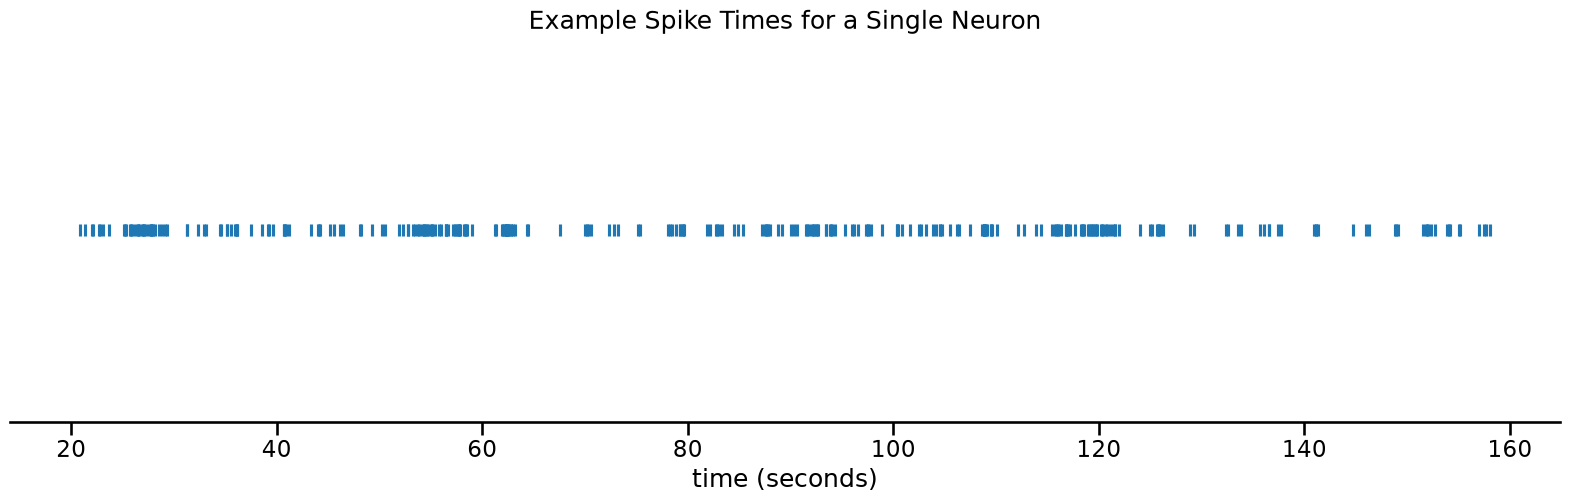

In [6]:
spikes_first_neuron = units_table['spike_times'].values[0][:300]

fig, ax = plt.subplots(figsize=(20, 5))
ax.scatter(spikes_first_neuron, np.ones_like(spikes_first_neuron), marker='|')
ax.set_xlabel('time (seconds)')
ax.set_yticks([])                        # y has no meaning here
for spine_position in ['top', 'right', 'left']:
    ax.spines[spine_position].set_visible(False)
ax.set_title('Example Spike Times for a Single Neuron')
plt.show()

<h3> How many units are in the units table?? </h3>

In [7]:
print('number of units in the table: %d' % len(units_table))

number of units in the table: 2285


### 1.4 Unit QC

That is a lot of units, but should we trust them all?

Neuropixels records many units at once, and the sorting is done by an algorithm rather than checked by hand, so some "units" may be noise or two neurons merged together. We keep only units that pass a few quality metrics:

- **isi_violations_ratio**: fraction of spikes too close together to be one neuron. Too high means noise or two neurons merged. *(lower is better)*
- **amplitude_cutoff**: the fraction of the neuron's spikes that fall below the spike-sorting algorithm's detection threshold. *(lower is better)*
- **presence_ratio**: the fraction of the session in which the neuron is observed. *(higher is better)*

#### Which cutoffs you use depends on your question. Loosen them if you do not need well-isolated units, tighten them if you do. These defaults are a reasonable start.

In [8]:
# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

968 of 2285 units passed quality control


### 1.5 Select neurons from MOs

MOs is a secondary motor cortex. If you think this is an odd place to start looking for signals about stimulus encoding, then hold on to that thought.

In [9]:
this_structure_units_table = good_units[good_units.structure == 'MOs']
print('%d good units in MOs (secondary motor cortex)' % len(this_structure_units_table))

196 good units in MOs (secondary motor cortex)


### Quick fill-in

*Fill in the blank to print how many of these MOs units there are.*

In [10]:
# 🏋️‍♂️🏋️‍♂️🏋️‍♂️ EXERCISE_TO_STUDENTS: fill in the blank, then run
# print('MOs units: %d' % len(________))
print('MOs units: %d' % len(this_structure_units_table))   # <- solution line, student_exercise

MOs units: 196


### Before we model, look with your eyes

##### For this, we want to estimate spike counts

This helper turns spikes into counts. Give it a neuron's spike times, the
stimulus onset times, and bin edges, and it returns a table of spike counts, one
row per trial and one column per time bin. `searchsorted` makes it fast.

In [11]:
def get_binned_triggered_spike_counts_fast(spike_times, stim_times, bins):
    """
    Fast peri-stimulus time histogram using searchsorted.

    Parameters
    ----------
    spike_times : 1D array_like, sorted
        Times of all spikes (e.g. in seconds).
    stim_times : 1D array_like
        Times of stimulus onsets.
    bins : 1D array_like
        Bin edges *relative* to stimulus (e.g. np.linspace(-0.1, 0.5, 61)).

    Returns
    -------
    counts : 2D ndarray, shape (n_trials, len(bins)-1)
        counts[i, j] is the number of spikes in bin j of trial i.
    """
    # ensure numpy arrays
    spike_times = np.asarray(spike_times)
    stim_times = np.asarray(stim_times)
    bins = np.asarray(bins)

    # If your spike_times isn't already sorted, uncomment:
    # spike_times = np.sort(spike_times)

    n_trials = stim_times.size
    n_bins = bins.size - 1
    counts = np.zeros((n_trials, n_bins), dtype=int)

    for i, stim in enumerate(stim_times):
        # compute the absolute edges for this trial
        edges = stim + bins
        # find the insertion indices for each edge
        spikes_before_edge = np.searchsorted(spike_times, edges, side='left')
        # differences between successive indices = counts per bin
        counts[i, :] = np.diff(spikes_before_edge)

    return counts

# Use spike counts to explore neural activity under varying stimuli

Some MOs neurons clearly fire differently for the two visual stimuli, vis1
and vis2. Some do not. We hold context fixed to visual blocks, so only the
stimulus changes between the two curves. Top row separates the stimuli, bottom row
does not. Selectivity is a property of some neurons, not all.

### Pick example neurons and set up the PSTH (peri-stimulus time histogram)

Context is fixed to visual blocks, so only the stimulus changes.

In [12]:
# example neurons for THIS session (759434_2025-02-04), MOs, vis1 vs vis2
# chosen by ranking every good MOs unit by d-prime in the 0 to 0.5 s window
VIS_SELECTIVE_INDEX_LIST = [6, 143, 2, 169]     # separate vis1 from vis2 (d' ~ 2.3 to 3.4)
VIS_SIMILAR_INDEX_LIST   = [33, 107, 158, 96]   # respond but do not separate (d' ~ 0)

# PSTH time bins, -0.5 to 1.0 s around onset, 50 ms wide
psth_bin_edge_array = np.arange(-0.5, 1.0 + 0.05, 0.05)
psth_bin_center_array = psth_bin_edge_array[:-1] + 0.05 / 2

### Get the visual-context trial times

In [13]:
# vis1 and vis2 onsets, visual context only (context fixed)
vis1_stim_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'vis'),
    'stim_start_time'].values
vis2_stim_time_array = trials.loc[
    (trials.stim_name == 'vis2') & (trials.rewarded_modality == 'vis'), # stim vis 2 under visual block
    'stim_start_time'].values
print('visual-context trials: vis1 = %d, vis2 = %d'
      % (len(vis1_stim_time_array), len(vis2_stim_time_array)))

visual-context trials: vis1 = 74, vis2 = 61


### A helper for one neuron's PSTH

In [14]:
def neuron_psth(neuron_row_index, stim_time_array):
    spike_time_array = this_structure_units_table.spike_times.values[neuron_row_index]
    count_array = get_binned_triggered_spike_counts_fast(
        spike_time_array, stim_time_array, psth_bin_edge_array)
    return count_array.mean(axis=0) / 0.05

### Plot the example neurons

Top row separates vis1 from vis2, bottom row does not.

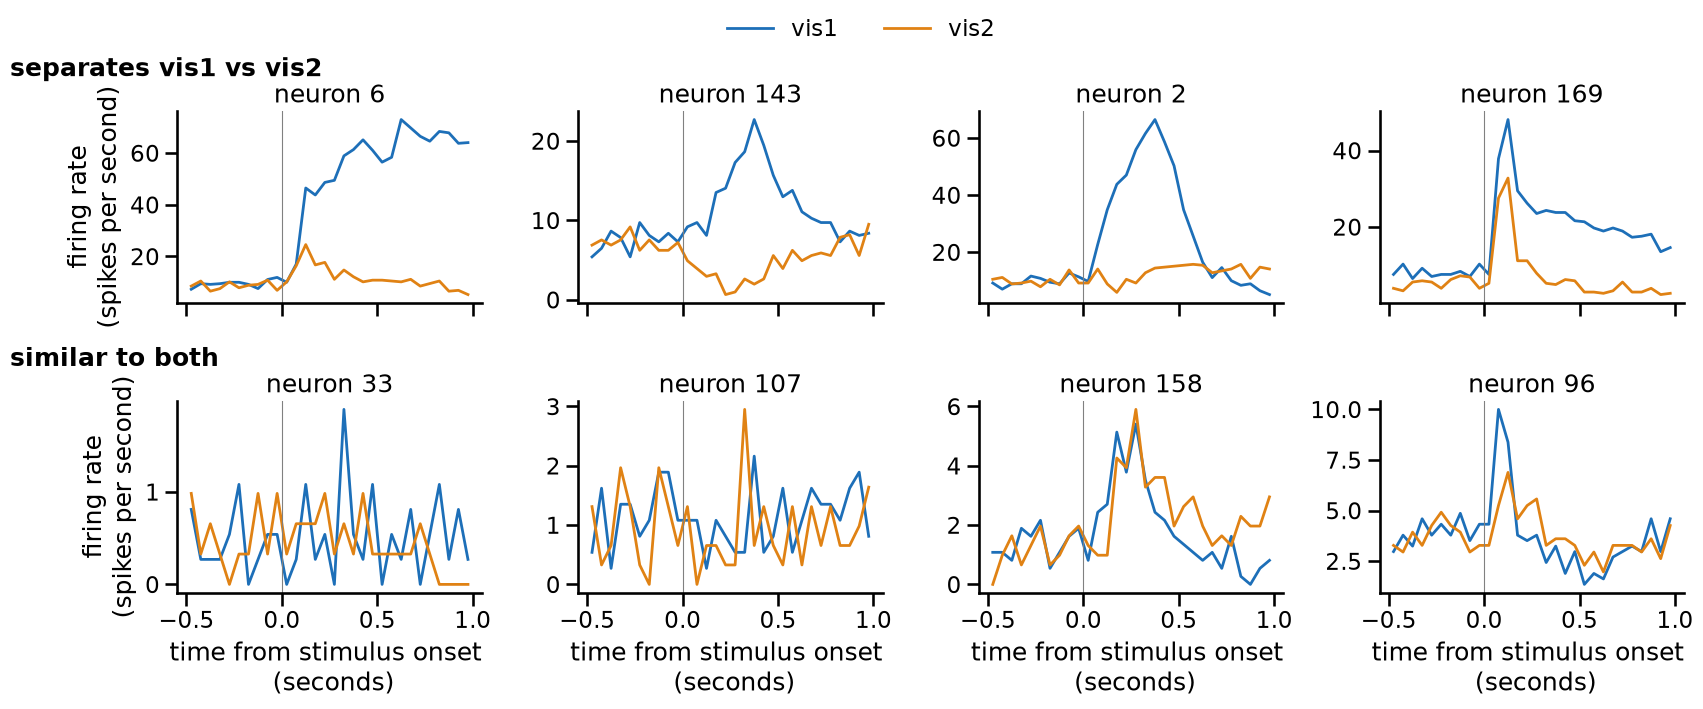

In [15]:
color_vis1 = '#1D6FB8'
color_vis2 = '#E08214'

fig, ax = plt.subplots(2, 4, figsize=(17, 7), sharex=True)
row_index_list = [VIS_SELECTIVE_INDEX_LIST, VIS_SIMILAR_INDEX_LIST]
row_text_list = ['separates vis1 vs vis2', 'similar to both']
for row in range(2):
    for col in range(4):
        neuron_row_index = row_index_list[row][col]
        single_ax = ax[row, col]
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(neuron_row_index, vis1_stim_time_array),
                       color=color_vis1, linewidth=2, label='vis1')
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(neuron_row_index, vis2_stim_time_array),
                       color=color_vis2, linewidth=2, label='vis2')
        single_ax.axvline(0, color='0.5', linewidth=0.8)
        single_ax.set_title('neuron %d' % neuron_row_index)
        sns.despine(ax=single_ax)
    ax[row, 0].set_ylabel('firing rate\n(spikes per second)')
    ax[row, 0].annotate(row_text_list[row], xy=(-0.55, 1.18),
                        xycoords='axes fraction', fontweight='bold')
for single_ax in ax[-1, :]:
    single_ax.set_xlabel('time from stimulus onset \n (seconds)')
handle_list, label_list = ax[0, 0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='',
           loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False)
fig.subplots_adjust(hspace=0.5, wspace=0.4)
fig.tight_layout()
plt.show()
# pay attention - context is fixed!! ask? todonmnm

# 2 Can we decode stimulus identity from a single neuron?

It is always going to be tempting to jump streight into modeling, and gloss over the actual data. Don't be tempted to do this! Looking at and understanding your  data is, at the end of the day, alway more important than whatever model you might fit. Afterall, if your data are bad, so is your model.

Fortunatly, someone here has already done a good chunk of the QC on our data. So here, "data" really means the spike times for a given unit.

With this in mind, lets look at the activity of a single neuron as the mouse is presented with its stimulus. First, we need some data.

### 2.1 Rasters and PSTHs

What we want to know right now is, how does this neuron respond to a stimulus?

To answer this, we need to grab a window of time around the when the stimulus was presented. We will then look at the only the spikes that happen within this window. 

We are going to make two types of plots to visualize these data. 

+ The first we call a **raster** plot. Here, we will represent each spike by a dot, and each trial as a row in our plot.
+ The raster plot is useful for visualizng activity accross trials, but it can be difficult to quantify. With this in mind, we will also make a **Peristimulus Time Histogoram** or **PSTH**. This is the averaged stimulus triggered average for the neuron or, equivalently, a histogram showing the average of the raster plot.

# Pick one neuron, and grab the spikes in a window around every stimulus onset.

In [16]:
# pick the first selective neuron (337) as our example
unit = VIS_SELECTIVE_INDEX_LIST[0]
# all spike times for that neuron
spike_times = this_structure_units_table.spike_times.values[unit]
# stimulus onset time for every trial
stim_times = trials.stim_start_time.values
print('neuron %d has %d spikes' % (unit, len(spike_times)))
print('first few stimulus onset times: %s' % np.round(stim_times[:5], 2))

neuron 6 has 73981 spikes
first few stimulus onset times: [2160.42 2166.84 2174.29 2181.18 2186.82]


### Collect one neuron's spikes around every stimulus

*For each trial, we grab this neuron's spikes near the stimulus and align them to onset, so we can stack all trials into a raster.*

In [17]:
# window around each stimulus: 0.5 s before to 2.0 s after onset
pre_window = 0.5
post_window = 2.0
bin_size = 0.05                                      # PSTH bin width (seconds)
bins = np.arange(-pre_window, post_window + bin_size, bin_size)   # bin edges
bin_centers = bins[:-1] + bin_size / 2               # bin centers, for plotting

# will hold, across all trials, each spike's time (aligned to onset) and its trial number
triggered_spike_times = []
triggered_trial_index = []

for i, stim_time in enumerate(stim_times):
    # keep this neuron's spikes that fall inside the trial's window
    mask = ((spike_times >= stim_time - pre_window) &
            (spike_times < stim_time + post_window))
    # subtract the stimulus onset time, so 0 now means "moment the stimulus appeared"
    trial_spikes = spike_times[mask] - stim_time
    triggered_spike_times.append(trial_spikes)
    # tag each of those spikes with this trial's index i
    triggered_trial_index.append(np.ones(len(trial_spikes)) * i)

print('collected spikes around %d trials' % len(stim_times))

collected spikes around 545 trials


Flatten into vectors for plotting.

In [18]:
triggered_spike_times = np.concatenate(triggered_spike_times)   # flatten list of per-trial arrays into one long array of spike times
triggered_trial_index = np.concatenate(triggered_trial_index)   # matching flat array, the trial number each spike belongs to

The raster shows every spike as a dot. The PSTH below averages them into a firing rate.

### The most selective neuron, up close

Neuron 337 was the strongest vis1 vs vis2 separator. Here is its raster and PSTH
across all trials, before we split by stimulus.

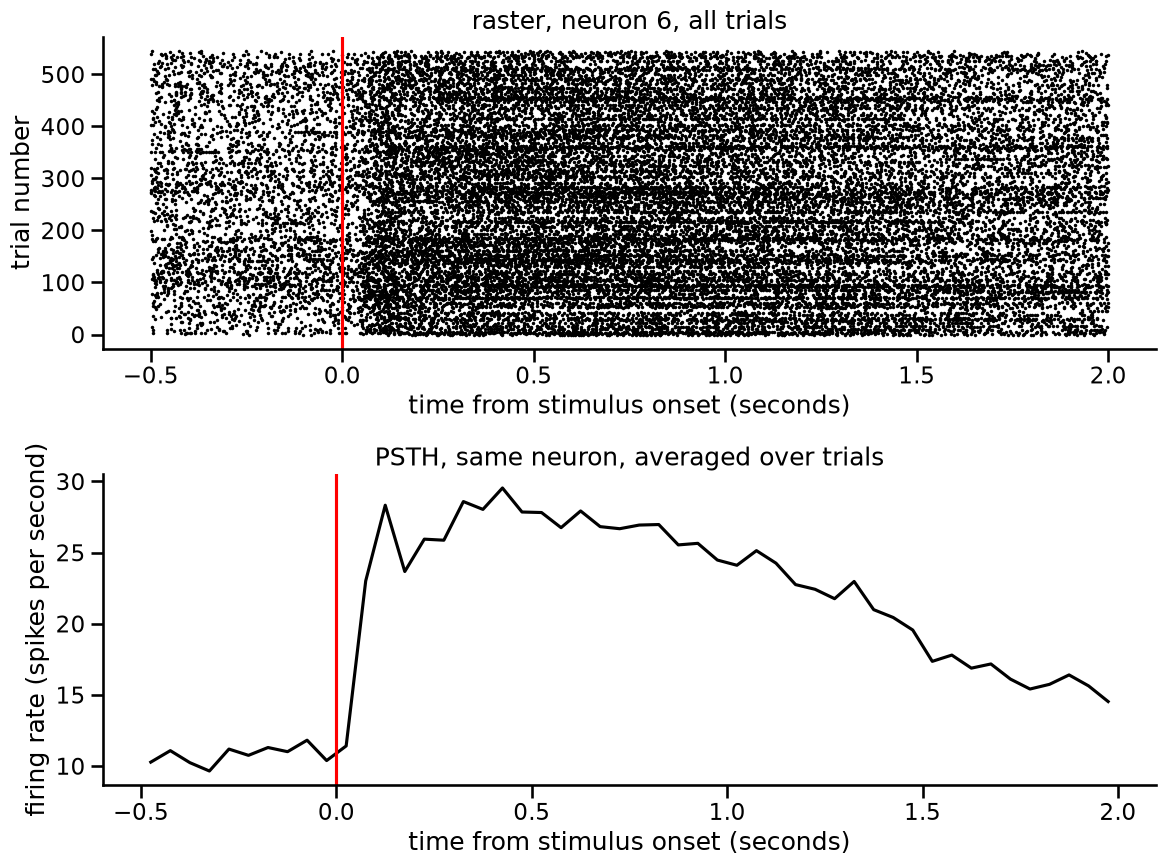

In [19]:
fig, ax = plt.subplots(nrows=2, figsize=(12, 9))
ax[0].scatter(triggered_spike_times, triggered_trial_index, s=1, c='k')
ax[0].axvline(0, c='r')
ax[0].set_xlabel('time from stimulus onset (seconds)')
ax[0].set_ylabel('trial number')
ax[0].set_title('raster, neuron %d, all trials' % unit)

count_array, _ = np.histogram(triggered_spike_times, bins=bins)
rate_array = count_array / len(stim_times) / bin_size
ax[1].plot(bin_centers, rate_array, c='k')
ax[1].axvline(0, c='r')
ax[1].set_xlabel('time from stimulus onset (seconds)')
ax[1].set_ylabel('firing rate (spikes per second)')
ax[1].set_title('PSTH, same neuron, averaged over trials')
for single_ax in ax:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

Great! We have a neuron that responds to the stimulus!

But remember our goal here- we want to know if we can decode the difference between stimuli from this neuron. With that in mind, lets try seperating out the different stimulus identities.

One handy way to do this seperation is to use numpy's ** unique ** function. Selecting return_inverse will give a easy way to sort the trial identities.

Figure out which stimulus was shown on each trial.

In [20]:
unq, stim_id = np.unique(trials.stim_name.values[triggered_trial_index.astype(int)],
                         return_inverse=True)
print('stimulus types present: %s' % unq.tolist())

stimulus types present: ['catch', 'sound1', 'sound2', 'vis1', 'vis2']


### Now split those same spikes by stimulus

*Does this neuron fire differently for vis1 versus vis2? Coloring each trial by its stimulus lets us see the difference the decoder will rely on.*

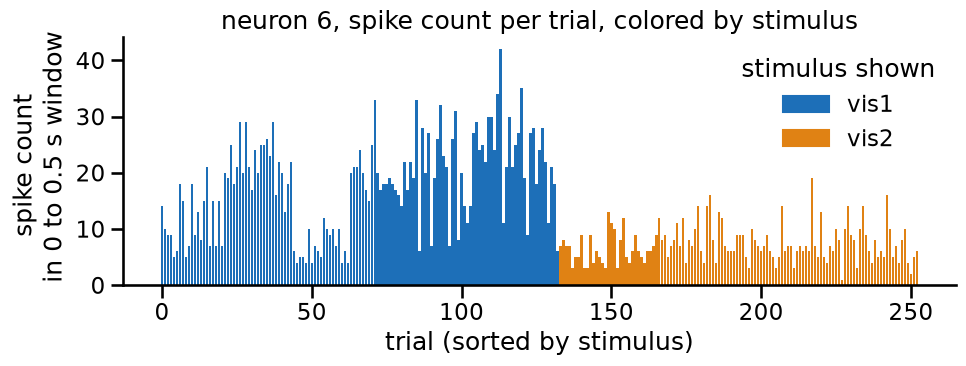

In [21]:
# spike count in 0 to 0.5 s for every vis1/vis2 trial of this neuron
example_neuron_row_index = VIS_SELECTIVE_INDEX_LIST[0]
count_window_bin_array = np.array([0.0, 0.5])
all_trial_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[example_neuron_row_index],
    trials.stim_start_time.values, count_window_bin_array).ravel()   # one count per trial
all_trial_stim_array = trials.stim_name.values                       # stimulus label per trial

keep_mask = np.isin(all_trial_stim_array, ['vis1', 'vis2'])          # keep the two visual stimuli
kept_count_array = all_trial_count_array[keep_mask]
kept_stim_array = all_trial_stim_array[keep_mask]

sort_order_array = np.argsort(kept_stim_array)                       # group vis1 bars, then vis2 bars
sorted_count_array = kept_count_array[sort_order_array]
sorted_stim_array = kept_stim_array[sort_order_array]

# one color per bar, by that trial's stimulus
bar_color_list = [color_vis1 if s == 'vis1' else color_vis2 for s in sorted_stim_array]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(len(sorted_count_array)), sorted_count_array, color=bar_color_list)
ax.set_xlabel('trial (sorted by stimulus)')
ax.set_ylabel('spike count \n in 0 to 0.5 s window')
ax.set_title('neuron %d, spike count per trial, colored by stimulus'
             % example_neuron_row_index)

# legend via proxy handles
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=color_vis1, label='vis1'),
                   Patch(color=color_vis2, label='vis2')],
          title='stimulus shown', frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

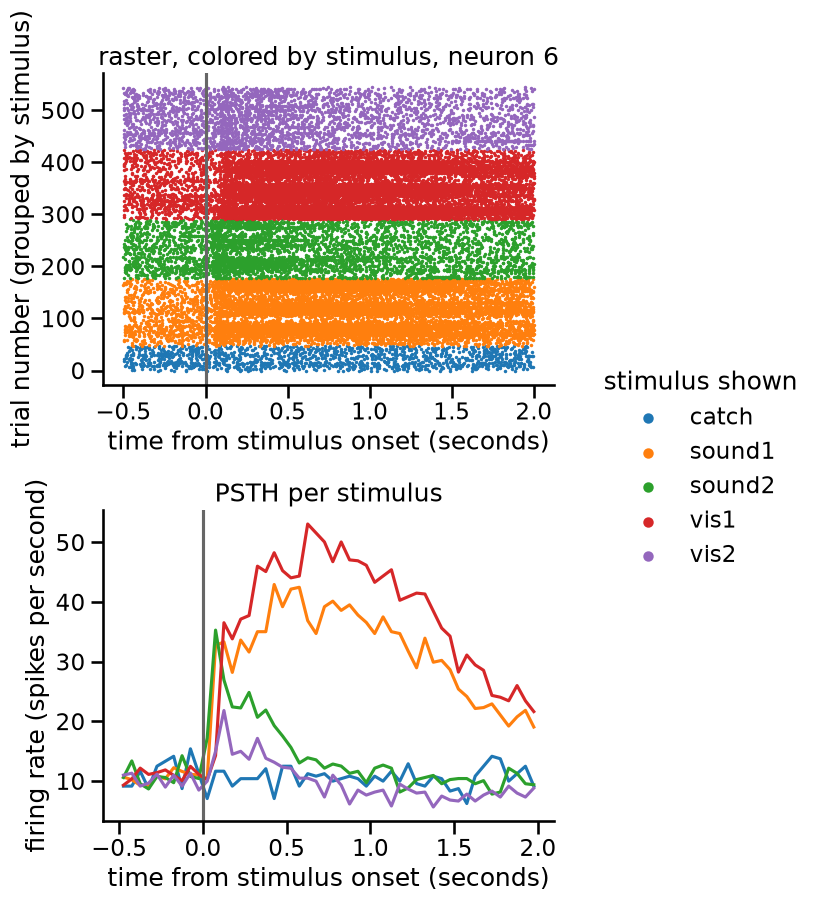

In [22]:
fig, ax = plt.subplots(nrows=2, figsize=(6, 9))
counter = 0
for stim_index in range(len(unq)):
    this_spikes = triggered_spike_times[stim_id == stim_index]
    _, this_trial_index = np.unique(triggered_trial_index[stim_id == stim_index],
                                    return_inverse=True)
    ax[0].scatter(this_spikes, counter + this_trial_index, s=1, label=unq[stim_index])
    counter += np.max(this_trial_index) + 1
    hist_array, _ = np.histogram(this_spikes, bins=bins)
    rate_array = hist_array / (np.max(this_trial_index) + 1) / bin_size
    ax[1].plot(bin_centers, rate_array, label=unq[stim_index])
ax[0].axvline(0, c='0.4')
ax[0].set_xlabel('time from stimulus onset (seconds)')
ax[0].set_ylabel('trial number (grouped by stimulus)')
ax[0].set_title('raster, colored by stimulus, neuron %d' % unit)
ax[1].axvline(0, c='0.4')
ax[1].set_xlabel('time from stimulus onset (seconds)')
ax[1].set_ylabel('firing rate (spikes per second)')
ax[1].set_title('PSTH per stimulus')
for single_ax in ax:
    sns.despine(ax=single_ax)
handle_list, label_list = ax[0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='stimulus shown',
           loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, markerscale=6)
fig.tight_layout()
plt.show()

# ---- HOMEWORK (optional) ----
# Plot the PSTH difference (vis1 minus vis2) for this neuron, so the moment the
# two stimuli diverge is a single curve crossing zero. Try it for a selective
# neuron and for a non-selective one, and compare.

### The linear classifier, in one picture

A **support vector machine** (SVM) draws the **decision boundary** that best
separates two classes of trials. In higher dimensions it is a **hyperplane**.
Of all separating lines, the SVM picks the one with the widest **margin**, the
biggest gap to the nearest points. Those nearest points are the **support
vectors**, and they alone pin the boundary. Move any other point and nothing
changes.

The illustration below shows the idea.

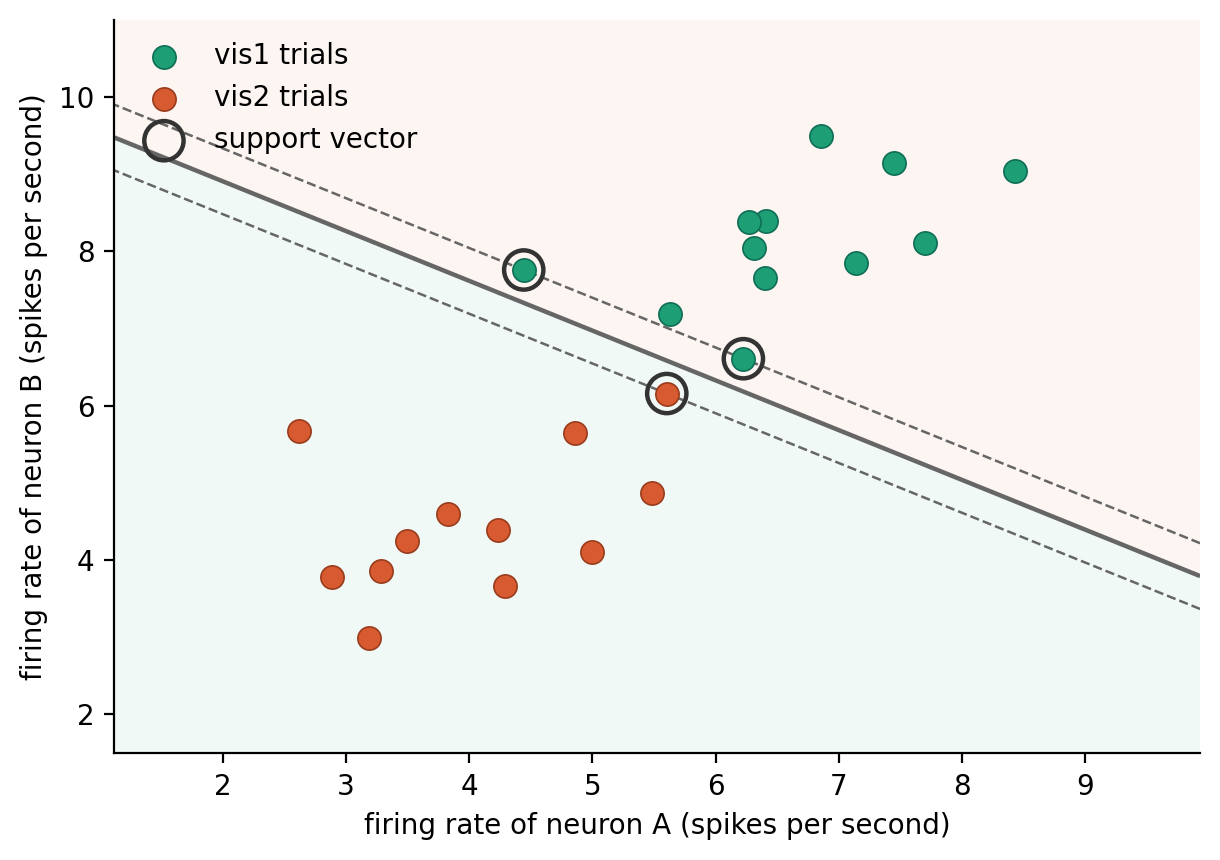

In [23]:
from IPython.display import Image, display
try:
    display(Image(filename='svm_margin_two_classes.png'))
except Exception as error:
    print('SVM illustration not found next to the notebook: %s' % error)


## Support Vector Machine

**Setup.** Data $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$, with $\mathbf{x}_i \in \mathbb{R}^d$ and $y_i \in \{-1, +1\}$. Decision function

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b, \qquad \hat{y} = \operatorname{sign}(f(\mathbf{x})).$$

**Geometric margin.** Distance of a point to the hyperplane is $\dfrac{y_i(\mathbf{w}^\top \mathbf{x}_i + b)}{\|\mathbf{w}\|}$. Fixing the functional margin to 1 for the closest points, the margin width is $\dfrac{2}{\|\mathbf{w}\|}$.

**Hard-margin primal.**

$$\min_{\mathbf{w}, b} \ \tfrac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1, \ \forall i.$$

SVM finds the hyperplane $\mathbf{w}^\top\mathbf{x}+b=0$ that separates two classes with the widest possible margin, which reduces to minimizing $\tfrac{1}{2}\|\mathbf{w}\|^2$ subject to every point lying on its correct side (with slack $\xi_i$ and penalty $C$ allowing some violations). Solving the dual shows the boundary depends only on a few "support vectors," and replacing inner products with a kernel $k(\mathbf{x}_i,\mathbf{x}_j)$ lets it separate classes that are not linearly separable.

### 2.3 Now let's try applying an SVM to a neuron!

Our neural data is high dimensional, which makes it hard to interpret. To keep things simple, let's take a small window from the spike train that gives us a decent chance of decoding information from this neuron.

Count each trial's spikes in the 0 to 0.5 s window, for vis1 and vis2, context fixed to visual blocks.

### Quick fill-in

*The response window below is 0 to 0.5 s. Change the numbers and see how the decoding changes. What window gives the best single-neuron decode?*

## preparing the data structure & labels

In [24]:
# ---- TWO-NEURON decoder ----
# We deliberately use TWO NON-SELECTIVE neurons here, so the decode is poor.
# That poor result is the motivation to move to the whole population later.
# (Students: swap in selective neurons, e.g. 6 and 143, and watch accuracy jump.)
two_neuron_index_list = [VIS_SIMILAR_INDEX_LIST[0], VIS_SIMILAR_INDEX_LIST[1]]  # neurons 33 and 107
count_window_bin_array = np.array([0.0, 0.5])   # 0 to 0.5 s after onset, one count per trial

# for each of the two neurons, spike count per vis1 trial and per vis2 trial
neuron_a_vis1_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[two_neuron_index_list[0]],
    vis1_stim_time_array, count_window_bin_array).ravel()
neuron_a_vis2_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[two_neuron_index_list[0]],
    vis2_stim_time_array, count_window_bin_array).ravel()
neuron_b_vis1_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[two_neuron_index_list[1]],
    vis1_stim_time_array, count_window_bin_array).ravel()
neuron_b_vis2_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[two_neuron_index_list[1]],
    vis2_stim_time_array, count_window_bin_array).ravel()

# stack into a 2-column feature matrix X (each row a trial, each column a neuron)
two_neuron_count_array = np.vstack([
    np.column_stack([neuron_a_vis1_count_array, neuron_b_vis1_count_array]),
    np.column_stack([neuron_a_vis2_count_array, neuron_b_vis2_count_array])])
two_neuron_label_array = np.array(
    ['vis1'] * len(neuron_a_vis1_count_array) + ['vis2'] * len(neuron_a_vis2_count_array))

print('two neurons %s, %d trials total (%d vis1, %d vis2)'
      % (two_neuron_index_list, len(two_neuron_label_array),
         len(neuron_a_vis1_count_array), len(neuron_a_vis2_count_array)))

two neurons [33, 107], 135 trials total (74 vis1, 61 vis2)


In [25]:
# names used by the training cells below
X_two_neuron_array = two_neuron_count_array          # (n_trials, 2)
y_two_neuron_array = two_neuron_label_array           # (n_trials,)

## Let's look at the data again. Below are the two spike-count distributions. 
The SVM places a single threshold between them. The histogram shows the real counts, the smooth curve is a kernel density estimate.

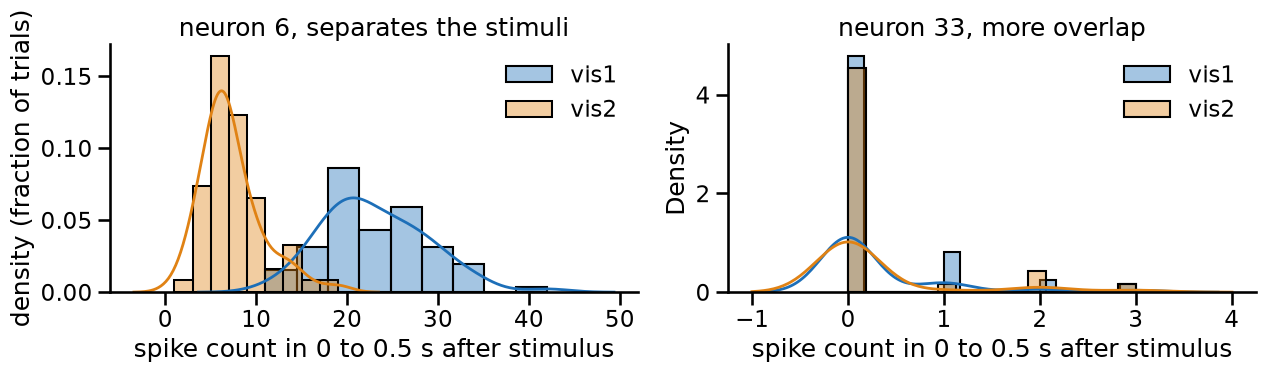

In [26]:
# ---- neurons shown in this figure (independent of the classifier) ----
selective_plot_index = VIS_SELECTIVE_INDEX_LIST[0]   # left panel: separates the two stimuli
overlap_plot_index   = VIS_SIMILAR_INDEX_LIST[0]    # right panel: distributions overlap a lot

# left neuron's spike counts (0 to 0.5 s) for vis1 and vis2
selective_vis1_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[selective_plot_index],
    vis1_stim_time_array, count_window_bin_array).ravel()
selective_vis2_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[selective_plot_index],
    vis2_stim_time_array, count_window_bin_array).ravel()

# right neuron's spike counts for vis1 and vis2
overlap_vis1_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[overlap_plot_index],
    vis1_stim_time_array, count_window_bin_array).ravel()
overlap_vis2_count_array = get_binned_triggered_spike_counts_fast(
    this_structure_units_table.spike_times.values[overlap_plot_index],
    vis2_stim_time_array, count_window_bin_array).ravel()

################# PLOT
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

# left panel: selective neuron
sns.histplot(selective_vis1_count_array, stat='density', color=color_vis1, alpha=0.4,
             label='vis1', ax=ax[0])
sns.histplot(selective_vis2_count_array, stat='density', color=color_vis2, alpha=0.4,
             label='vis2', ax=ax[0])
sns.kdeplot(selective_vis1_count_array, color=color_vis1, linewidth=2, ax=ax[0])
sns.kdeplot(selective_vis2_count_array, color=color_vis2, linewidth=2, ax=ax[0])
ax[0].set_xlabel('spike count in 0 to 0.5 s after stimulus')
ax[0].set_ylabel('density (fraction of trials)')
ax[0].set_title('neuron %d, separates the stimuli' % selective_plot_index)
ax[0].legend(frameon=False)
sns.despine(ax=ax[0])

# right panel: overlapping neuron
sns.histplot(overlap_vis1_count_array, stat='density', color=color_vis1, alpha=0.4,
             label='vis1', ax=ax[1])
sns.histplot(overlap_vis2_count_array, stat='density', color=color_vis2, alpha=0.4,
             label='vis2', ax=ax[1])
sns.kdeplot(overlap_vis1_count_array, color=color_vis1, linewidth=2, ax=ax[1])
sns.kdeplot(overlap_vis2_count_array, color=color_vis2, linewidth=2, ax=ax[1])
ax[1].set_xlabel('spike count in 0 to 0.5 s after stimulus')
ax[1].set_title('neuron %d, more overlap' % overlap_plot_index)
ax[1].legend(frameon=False)
sns.despine(ax=ax[1])

fig.tight_layout()
plt.show() # todo - use the 2 neuron example for the svm

### The two-neuron decoder, seen in 2D

With two neurons the decision boundary is a line in a plane. Each axis is one
neuron's spike count. Because both neurons are non-selective, the two stimulus
clouds overlap heavily, so the line cannot separate them well. That is the point.

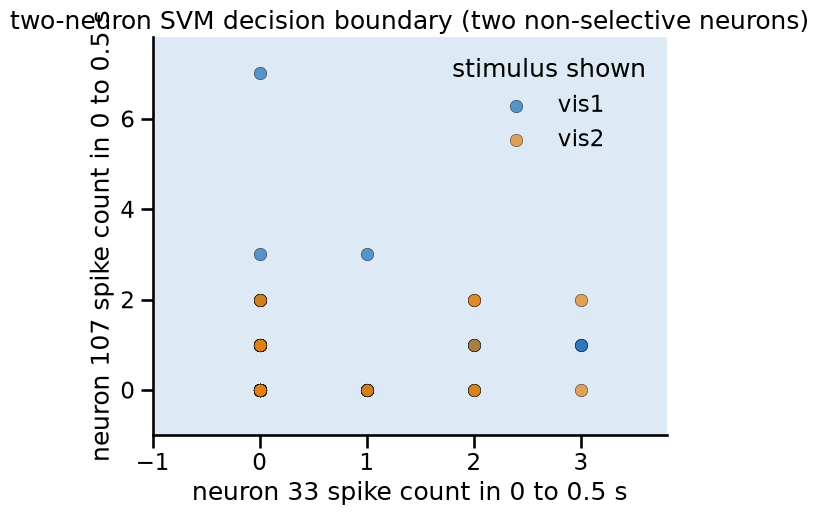

In [27]:
# fit a 2-neuron SVM and draw its decision boundary in the plane
two_neuron_svc = LinearSVC(max_iter=5000)
two_neuron_svc.fit(X_two_neuron_array, y_two_neuron_array)

# grid over the two neuron-count axes
x_min, x_max = X_two_neuron_array[:, 0].min() - 1, X_two_neuron_array[:, 0].max() + 1
y_min, y_max = X_two_neuron_array[:, 1].min() - 1, X_two_neuron_array[:, 1].max() + 1
grid_step = 0.2
xx_array, yy_array = np.meshgrid(np.arange(x_min, x_max, grid_step),
                                 np.arange(y_min, y_max, grid_step))
grid_prediction_array = two_neuron_svc.predict(
    np.column_stack([xx_array.ravel(), yy_array.ravel()])).reshape(xx_array.shape)
grid_code_array = (grid_prediction_array == 'vis2').astype(int)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.contourf(xx_array, yy_array, grid_code_array, alpha=0.15,
            cmap=plt.matplotlib.colors.ListedColormap([color_vis1, color_vis2]))
is_vis1_mask = (y_two_neuron_array == 'vis1')
ax.scatter(X_two_neuron_array[is_vis1_mask, 0], X_two_neuron_array[is_vis1_mask, 1],
           color=color_vis1, edgecolor='k', linewidth=0.4, label='vis1', alpha=0.7)
ax.scatter(X_two_neuron_array[~is_vis1_mask, 0], X_two_neuron_array[~is_vis1_mask, 1],
           color=color_vis2, edgecolor='k', linewidth=0.4, label='vis2', alpha=0.7)
ax.set_xlabel('neuron %d spike count in 0 to 0.5 s' % two_neuron_index_list[0])
ax.set_ylabel('neuron %d spike count in 0 to 0.5 s' % two_neuron_index_list[1])
ax.set_title('two-neuron SVM decision boundary (two non-selective neurons)')
ax.legend(title='stimulus shown', frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

🧠 **THINK!**

*The neuron on the left separated the two stimuli cleanly. The neuron on the right has two distributions that overlap much more. Before you run the decoder on it, predict: will the SVM do better or worse here, and why?*

# Training a decoder

<h3> Ready? </h3>
Go ahead and fit a linear SCV to the training data!

In [28]:
# fit the two-neuron decoder on a train/test split
x_train, x_test, y_train, y_test = train_test_split(
    X_two_neuron_array, y_two_neuron_array, random_state=0)

print('train trials: %d, test trials: %d' % (len(y_train), len(y_test)))
two_neuron_svc = LinearSVC(max_iter=5000)
two_neuron_svc.fit(x_train, y_train)
two_neuron_accuracy = two_neuron_svc.score(x_test, y_test)
print('two-neuron decoder is correct on %.0f%% of held-out trials'
      % (100 * two_neuron_accuracy))

train trials: 101, test trials: 34
two-neuron decoder is correct on 47% of held-out trials


### Instead of one train/test split, why not cross-validate?

*A single split can be lucky or unlucky. Cross-validation tests on every trial in turn, giving a fairer estimate.*

> **Reminder, cross-validation.** (Shailaja covered this in the morning.) A single train/test split grades the decoder on one held-out chunk, which can be lucky or unlucky. **K-fold cross-validation** splits the trials into k parts, trains on k-1 and tests on the one left out, and repeats so every trial is tested once. We report the average across folds, a fairer estimate, and the spread across folds shows how stable it is. **Why does this matter?** Because a single lucky split can make a decoder look better than it is.

In [29]:
# cross-validated score (5-fold), a fairer estimate than the single split above
from sklearn.model_selection import cross_val_score, cross_val_predict
two_neuron_cv_array = cross_val_score(
    LinearSVC(max_iter=5000), X_two_neuron_array, y_two_neuron_array, cv=5)

print('two-neuron cross-validated accuracy: %.0f%% (folds %.0f to %.0f%%)'
      % (100 * two_neuron_cv_array.mean(),
         100 * two_neuron_cv_array.min(), 100 * two_neuron_cv_array.max()))

two-neuron cross-validated accuracy: 54% (folds 52 to 56%)


Is this any good? The useful question is how much better the classifier does than guessing by chance. For two balanced classes like vis1 and vis2, chance is 50%, so we want to be well above that.

It is worth digging a little deeper into the predictions. When the classifier guesses wrong, the mistakes often have structure. A confusion matrix shows, for each true stimulus, how its predictions were distributed.

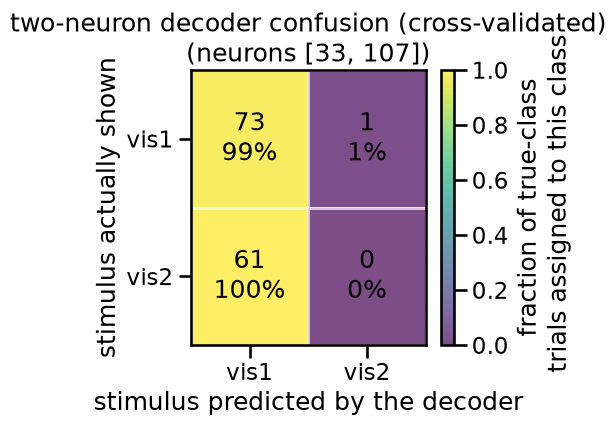

In [30]:
# CROSS-VALIDATED confusion matrix: every trial is predicted while held out
stim_name_array = np.array(['vis1', 'vis2'])        # the two classes

two_neuron_cv_prediction_array = cross_val_predict(
    LinearSVC(max_iter=5000), X_two_neuron_array, y_two_neuron_array, cv=5)


def plot_confusion(y_true, y_pred, label_array, title):
    count_array = confusion_matrix(y_true, y_pred, labels=label_array)          # raw counts
    fraction_array = count_array / count_array.sum(axis=1, keepdims=True)       # row-normalised (each true class sums to 1)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    mesh = ax.pcolormesh(fraction_array, cmap='viridis', alpha=0.7,
                         edgecolor='white', linewidth=2)                        # colored cells, white edges
    for r in range(len(label_array)):                                          # write count + percent in each cell
        for c in range(len(label_array)):
            ax.text(c + 0.5, r + 0.5, '%d\n%.0f%%'
                    % (count_array[r, c], 100 * fraction_array[r, c]),
                    ha='center', va='center', color='black')
    ax.set_xticks(np.arange(len(label_array)) + 0.5)
    ax.set_yticks(np.arange(len(label_array)) + 0.5)
    ax.set_xticklabels(label_array)
    ax.set_yticklabels(label_array)
    ax.invert_yaxis()                                                          # put first class at top
    ax.set_xlabel('stimulus predicted by the decoder')
    ax.set_ylabel('stimulus actually shown')
    ax.set_title(title)
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label('fraction of true-class\n trials assigned to this class')
    fig.tight_layout()
    plt.show()


plot_confusion(y_two_neuron_array, two_neuron_cv_prediction_array, stim_name_array,
               'two-neuron decoder confusion (cross-validated)\n(neurons %s)'
               % two_neuron_index_list)

### 🏋️‍♂️🏋️‍♂️🏋️‍♂️ Exercise time

*Change `example_neuron_row_index` to three other neurons of your choice (try some from `VIS_SIMILAR_INDEX_LIST`, and some numbers you pick at random). Re-run the single-neuron decode for each. Does a less selective neuron still beat chance? Compare what you found with your neighbor.*



In [31]:

# EXERCISE_TO_STUDENTS: try a different neuron here, then re-run the cells above
# example_neuron_row_index = 123


One neuron already beats a coin flip. But we recorded a whole population, so lets use all of MOs at once.

# 3.0 Now for a neural population.
### instead of predicting based on one neuron - use the population

While the mathematical formalizim is useful to understand what our chosen neuron is doing here, if we are being honest its probably overkill for understanding this single neurons activity. There are, in fact, whole classes of regression models that might be better suited for asking what information a neuron encodes. 

Why, then, have we spent so much time on this example? Decoding gives us a mathematical way to look at what information we can extract from a neural population. As this population becomes larger, however, it can become increasingly difficult to visualize and intuite what our decoder is doing under the hood. Starting with this one-dimension example will help with inuition as we move to this harder case.

To start, lets use decoding to take a hard look at the timescale of MOs' encoding of stimulus identity. 

Doing this is going to require a fair bit of data wrangling. Just as before, we needed to get the number of spikes per trial. But if we are looking over time and over neurons, we need to get the number of spikes for each neuron on each trial. 

Here is one way to do this, though you will notice that it is a little on the slow side.

Each **row is a trial (a sample)**, each **column is a neuron (a feature)**,
and the value is that neuron's **spike count** in the 0 to 0.5 s window. This is a
count, not a rate.

# Build the population decoder input, one row per trial, one column per neuron.

In [32]:
decode_bin_edge_array = np.arange(-0.3, 2.0, 0.1)          # 100 ms bin edges, -0.3 to 2.0 s

# pick trials: vis1 and vis2, visual context only
decode_trial_mask = (trials.stim_name.isin(['vis1', 'vis2']) &
                     (trials.rewarded_modality == 'vis'))
decode_stim_time_array = trials.loc[decode_trial_mask, 'stim_start_time'].values  # their onset times
decode_label_array = trials.loc[decode_trial_mask, 'stim_name'].values            # their stimulus labels (y)
print('%d visual-context trials go into the decoder' % len(decode_label_array))

n_neurons = len(this_structure_units_table)               # number of MOs neurons
# empty tensor: neurons x trials x time bins
population_tensor = np.zeros((n_neurons, len(decode_stim_time_array),
                              len(decode_bin_edge_array) - 1))
for neuron_row_index in range(n_neurons):                 # fill one neuron at a time
    population_tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
        this_structure_units_table.spike_times.values[neuron_row_index],
        decode_stim_time_array, decode_bin_edge_array)    # binned spike counts for this neuron


# here we take just the stimulus presentation time 
window_bin_slice = slice(3, 9)                            # bins 3 to 8 = 0 to 0.5 s after onset



# sum spikes in that window -> one count per neuron per trial, then transpose to (trials, neurons)
population_count_array = np.sum(population_tensor[:, :, window_bin_slice], axis=2).T
print('input matrix shape (trials, neurons) = %s' % (population_count_array.shape,))

# safety check: one row per trial
assert population_count_array.shape[0] == len(decode_label_array), \
    'row count (%d) must equal number of trials (%d)' % (
        population_count_array.shape[0], len(decode_label_array))

135 visual-context trials go into the decoder
input matrix shape (trials, neurons) = (135, 196)


### so what does the decoder actually see? let's take a look

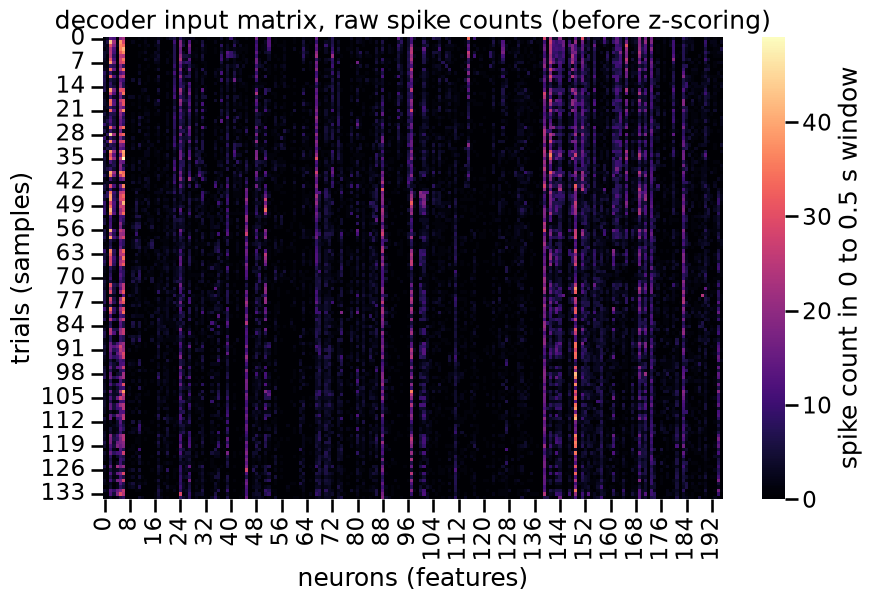

In [33]:
# raw spike counts, before any normalization
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(population_count_array, cmap='magma',  ax=ax, #robust=True,
            cbar_kws={'label': 'spike count in 0 to 0.5 s window'})
ax.set_xlabel('neurons (features)')
ax.set_ylabel('trials (samples)')
ax.set_title('decoder input matrix, raw spike counts (before z-scoring)')
plt.show()

### Why z-score?

Neurons fire at very different rates. A high-firing neuron would dominate the heatmap, and some classifiers, just because of its scale. **Z-scoring** each neuron puts every neuron on the same footing, so the *pattern* across neurons is what matters, not the raw rate.

For a neuron with spike count $x$ on each trial:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is that neuron's mean spike count across trials and $\sigma$ is its standard deviation. After z-scoring, every neuron has mean 0 and standard deviation 1.

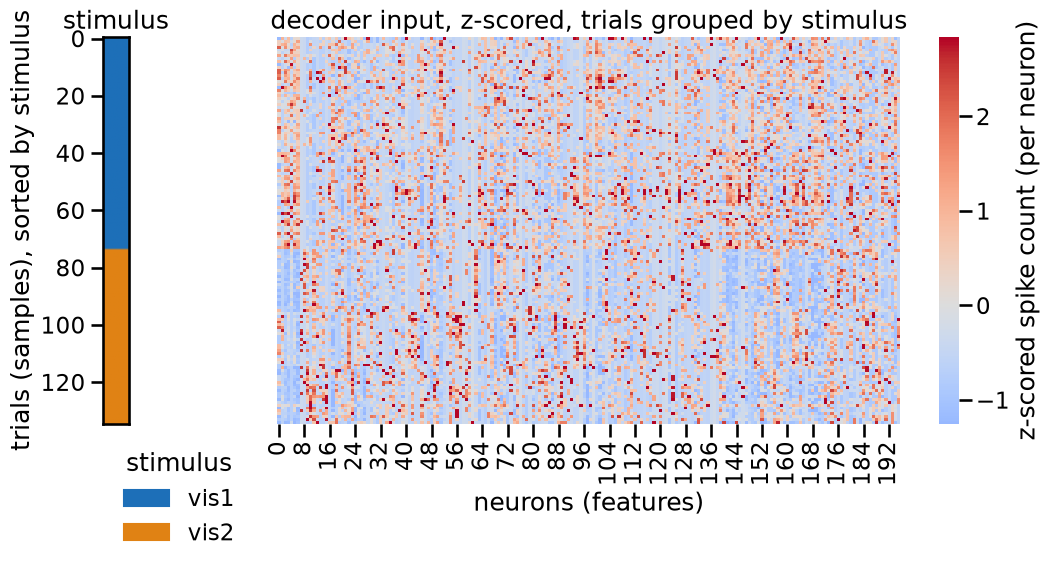

In [34]:
from sklearn.preprocessing import StandardScaler

# sort trials by stimulus so vis1 and vis2 form two blocks
sort_order_array = np.argsort(decode_label_array)
sorted_zscore_array = StandardScaler().fit_transform(population_count_array)[sort_order_array]
sorted_label_array = decode_label_array[sort_order_array]

fig, ax = plt.subplots(1, 2, figsize=(11, 6),
                       gridspec_kw={'width_ratios': [1, 30]})

# left strip: stimulus of each trial (row)
stim_code_array = (sorted_label_array == 'vis2').astype(int).reshape(-1, 1)
ax[0].imshow(stim_code_array, aspect='auto',
             cmap=plt.matplotlib.colors.ListedColormap([color_vis1, color_vis2]))
ax[0].set_xticks([])
ax[0].set_ylabel('trials (samples), sorted by stimulus')
ax[0].set_title('stimulus')

# right: the z-scored matrix
sns.heatmap(sorted_zscore_array, cmap='coolwarm', center=0, robust=True, ax=ax[1],
            cbar_kws={'label': 'z-scored spike count (per neuron)'})
ax[1].set_xlabel('neurons (features)')
ax[1].set_yticks([])
ax[1].set_title('decoder input, z-scored, trials grouped by stimulus')

fig.tight_layout()
legend_handle_list = [Patch(color=color_vis1, label='vis1'),
                      Patch(color=color_vis2, label='vis2')]
ax[0].legend(handles=legend_handle_list, title='stimulus',
             loc='upper left', bbox_to_anchor=(0, -0.02), frameon=False)

fig.tight_layout()
plt.show()


🧠 **THINK!**

*Can you spot the two stimuli by eye in this matrix? Probably not. So how can the decoder tell them apart? Talk it over with your neighbor.*

Fit the population decoder, same recipe as one neuron with more features.

In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    population_count_array, decode_label_array, random_state=0)
population_svc = LinearSVC(max_iter=5000)
population_svc.fit(x_train, y_train)
population_accuracy = population_svc.score(x_test, y_test)
print('population decoder is correct on %.0f%% of held-out trials'
      % (100 * population_accuracy))

# cross-validated score (5-fold)
population_cv_array = cross_val_score(
    LinearSVC(max_iter=5000), population_count_array, decode_label_array, cv=5)
print('population cross-validated accuracy: %.0f%% (folds %.0f to %.0f%%)'
      % (100 * population_cv_array.mean(),
         100 * population_cv_array.min(), 100 * population_cv_array.max()))

population decoder is correct on 97% of held-out trials
population cross-validated accuracy: 96% (folds 96 to 96%)


### The confusion matrix for the population decoder.

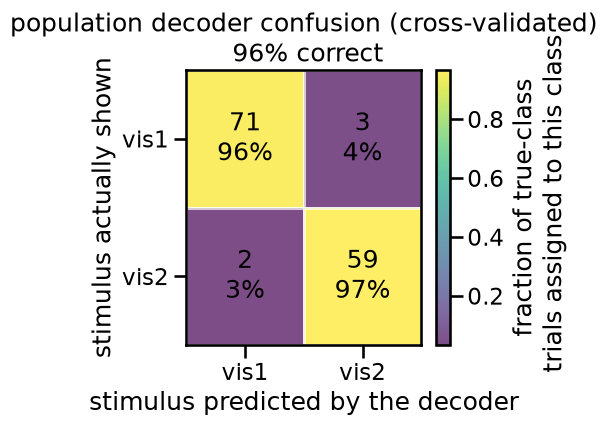

In [36]:
# CROSS-VALIDATED population confusion matrix (not a single train/test split)
population_cv_prediction_array = cross_val_predict(
    LinearSVC(max_iter=5000), population_count_array, decode_label_array, cv=5)
plot_confusion(decode_label_array, population_cv_prediction_array, stim_name_array,
               'population decoder confusion (cross-validated)\n %.0f%% correct'
               % (100 * population_cv_array.mean()))

## 3.5 How many neurons do we need?

One neuron barely beat chance, two non-selective neurons did poorly, and the
whole population did well. So how does accuracy grow as we add neurons? We take
random subsets of MOs neurons of increasing size, cross-validate the decoder on
each, and plot accuracy against the number of neurons. The shaded band is the
spread across random subsets.

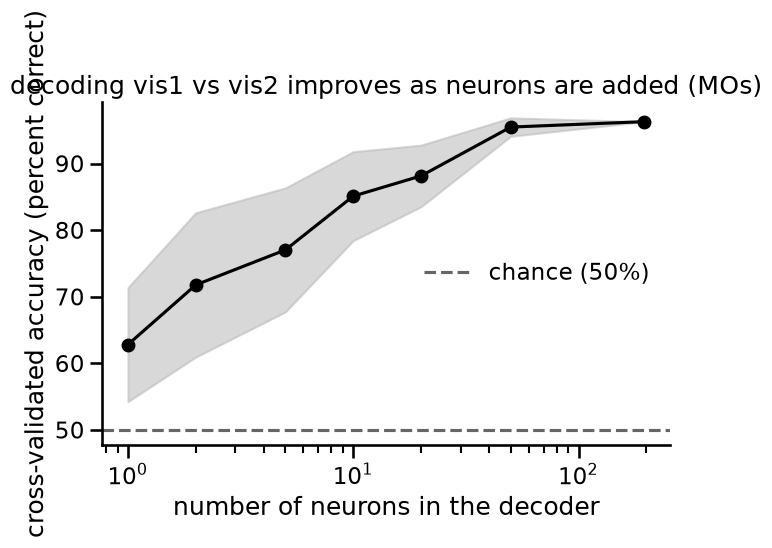

In [37]:
# accuracy as a function of the number of neurons in the decoder
neuron_count_list = [1, 2, 5, 10, 20, 50, population_count_array.shape[1]]
neuron_count_list = sorted(set(n for n in neuron_count_list
                               if n <= population_count_array.shape[1]))
n_repeat = 10                       # random subsets per size, for the error band
rng = np.random.default_rng(0)

mean_accuracy_list = []
std_accuracy_list = []
for n_neurons_in_subset in neuron_count_list:
    repeat_accuracy_list = []
    for _ in range(n_repeat):
        column_choice_array = rng.choice(population_count_array.shape[1],
                                         size=n_neurons_in_subset, replace=False)
        subset_count_array = population_count_array[:, column_choice_array]
        subset_cv_array = cross_val_score(
            LinearSVC(max_iter=5000), subset_count_array, decode_label_array, cv=5)
        repeat_accuracy_list.append(subset_cv_array.mean())
    mean_accuracy_list.append(np.mean(repeat_accuracy_list))
    std_accuracy_list.append(np.std(repeat_accuracy_list))

mean_accuracy_array = np.array(mean_accuracy_list)
std_accuracy_array = np.array(std_accuracy_list)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(neuron_count_list, 100 * mean_accuracy_array, marker='o', color='k')
ax.fill_between(neuron_count_list,
                100 * (mean_accuracy_array - std_accuracy_array),
                100 * (mean_accuracy_array + std_accuracy_array),
                color='0.7', alpha=0.5)
ax.axhline(50, linestyle='--', color='0.4', label='chance (50%)')
ax.set_xscale('log')
ax.set_xlabel('number of neurons in the decoder')
ax.set_ylabel('cross-validated accuracy (percent correct)')
ax.set_title('decoding vis1 vs vis2 improves as neurons are added (MOs)')
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### Exercise time! 

*So far we only looked at MOs. Try a different brain area. Change the `structure` filter (in section 1.5) to one of these and re-run the population decode:*

*Visual areas: `VISp`, `VISl`, `VISrl`, `VISam`, `VISpm`.*
*Frontal / association: `MOs`, `ACAd`, `PL`, `ORB`.*
*Other: `CP` (striatum), `LGd` (visual thalamus).*

*Half the table try a visual area, half try a frontal area. Does a sensory area beat MOs at decoding the visual stimulus? Compare and discuss why.*

```python
# EXERCISE_TO_STUDENTS: change the area, then re-run from section 1.5 down
# this_structure_units_table = good_units[good_units.structure == 'VISp']
```

What this means is that we can, using all of our MOs neurons, very reliably decode stimulus identity.  But we can use our new decoding technique to dig deeper into the behavior of the neural population within our chosen time window.

### When can we read out the stimulus?

We fit a separate decoder for each 100 ms time bin and plot its accuracy, to see when stimulus information appears in MOs. Each point is one decoder. Gray dots are the five cross-validation folds, blue dots the median. The dashed line is chance, the vertical line is stimulus onset.

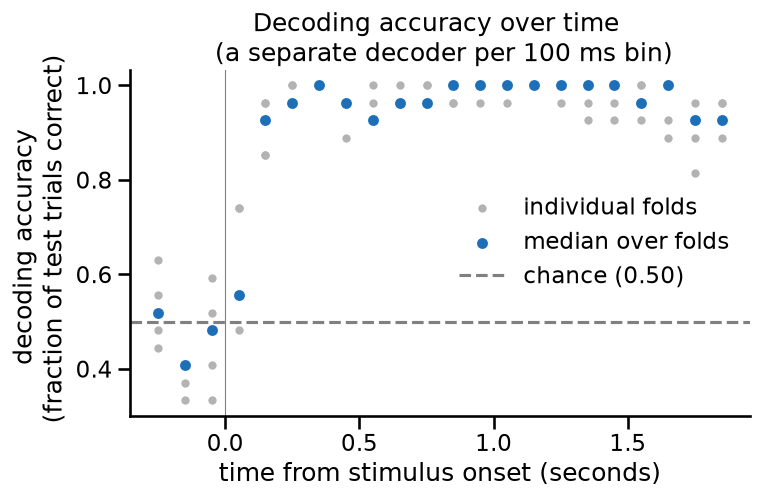

In [38]:
bin_center_array = (decode_bin_edge_array[:-1]
                    + np.median(np.diff(decode_bin_edge_array)) / 2)   # center of each time bin, for the x-axis
n_fold = 5                                                             # number of cross-validation folds
per_bin_score_array = np.empty((len(decode_bin_edge_array) - 1, n_fold))  # accuracy per bin (rows) per fold (cols)
for bin_index in range(len(decode_bin_edge_array) - 1):                # loop over time bins
    single_bin_feature_array = population_tensor[:, :, bin_index].T    # all neurons' counts in this bin, shape (trials, neurons)
    per_bin_score_array[bin_index] = cross_validate(                  # fit + score a fresh decoder for this bin
        LinearSVC(max_iter=5000), single_bin_feature_array,
        decode_label_array, cv=n_fold)['test_score']                  # keep the test accuracy of each fold
median_score_array = np.median(per_bin_score_array, axis=1)           # median accuracy across folds, per bin
fig, ax = plt.subplots(figsize=(8, 4.5))
for fold_index in range(n_fold):                                      # plot each fold's accuracy as gray dots
    ax.scatter(bin_center_array, per_bin_score_array[:, fold_index],
               color='0.7', s=20, zorder=2,
               label='individual folds' if fold_index == 0 else None)  # label only once in the legend
ax.scatter(bin_center_array, median_score_array, color='#1D6FB8', s=40,
           zorder=3, label='median over folds')                       # median as blue dots
ax.axhline(0.5, linestyle='--', color='0.5', label='chance (0.50)')   # two-class chance level
ax.axvline(0, color='0.5', linewidth=0.8)                             # stimulus onset at time 0
#ax.set_ylim(0, 1)                                                     # accuracy ranges 0 to 1
ax.set_xlabel('time from stimulus onset (seconds)')
ax.set_ylabel('decoding accuracy \n (fraction of test trials correct)')
ax.set_title('Decoding accuracy over time \n (a separate decoder per 100 ms bin)')
ax.legend(frameon=False)
sns.despine(ax=ax)                                                    # remove top and right spines
plt.show()

🧠 **THINK!**

*Why does accuracy climb after the stimulus and then fall again later in the trial? What might the MOs population be doing in the later part of the trial? Discuss with your neighbor before moving on.*

## 4. 🏋️‍♂️🏋️‍♂️🏋️‍♂️ Exercise Time!  
### Your turn, decode the two sounds (using your preferred time window in the trial)

The task also has two auditory stimuli, **sound1**  and **sound2** .

Copy the population recipe from section 3, but decode sound1 vs
sound2, with context fixed to auditory blocks.

1. Trial mask: `trials.stim_name.isin(['sound1', 'sound2'])` and
   `trials.rewarded_modality == 'aud'`.
2. Reuse `get_binned_triggered_spike_counts_fast`.
3. Print the held-out accuracy with a labeled `print`.

Guess first: does MOs decode sounds as well as it decodes the visual stimuli?

Write your solution in the cell below.

**Student template (fill the blanks, then comment out the SOLUTION cell below).**

```python
# sound1 and sound2 onsets, auditory context only
sound1_time_array = trials.loc[
    (trials.stim_name == '____') & (trials.rewarded_modality == '____'),
    'stim_start_time'].values
sound2_time_array = trials.loc[
    (trials.stim_name == '____') & (trials.rewarded_modality == '____'),
    'stim_start_time'].values

# stack onsets and labels
sound_time_array  = np.concatenate([sound1_time_array, sound2_time_array])
sound_label_array = np.array(['sound1'] * len(sound1_time_array)
                             + ['sound2'] * len(sound2_time_array))

# build the population matrix: one row per trial, one column per neuron
n_neurons = len(this_structure_units_table)
sound_count_array = np.zeros((len(sound_time_array), n_neurons))
for neuron_row_index in range(n_neurons):
    sound_count_array[:, neuron_row_index] = get_binned_triggered_spike_counts_fast(
        this_structure_units_table.spike_times.values[neuron_row_index],
        sound_time_array, np.array([____, ____])).ravel()

# cross-validate the decoder and print the accuracy
sound_cv_array = cross_val_score(LinearSVC(max_iter=5000),
                                 ____, ____, cv=5)
print('sound1 vs sound2 population accuracy: %.0f%%' % (100 * sound_cv_array.mean()))
```

In [39]:
# ===== SOLUTION CELL (delete or comment out before giving to students) =====  #SOLUTION
# decode sound1 vs sound2, auditory context only, using the whole MOs population  #SOLUTION
sound1_time_array = trials.loc[                                                    #SOLUTION
    (trials.stim_name == 'sound1') & (trials.rewarded_modality == 'aud'),          #SOLUTION
    'stim_start_time'].values                                                      #SOLUTION
sound2_time_array = trials.loc[                                                    #SOLUTION
    (trials.stim_name == 'sound2') & (trials.rewarded_modality == 'aud'),          #SOLUTION
    'stim_start_time'].values                                                      #SOLUTION
sound_time_array = np.concatenate([sound1_time_array, sound2_time_array])          #SOLUTION
sound_label_array = np.array(                                                      #SOLUTION
    ['sound1'] * len(sound1_time_array) + ['sound2'] * len(sound2_time_array))     #SOLUTION

n_neurons = len(this_structure_units_table)                                        #SOLUTION
sound_count_array = np.zeros((len(sound_time_array), n_neurons))                    #SOLUTION
for neuron_row_index in range(n_neurons):                                          #SOLUTION
    sound_count_array[:, neuron_row_index] = get_binned_triggered_spike_counts_fast(#SOLUTION
        this_structure_units_table.spike_times.values[neuron_row_index],           #SOLUTION
        sound_time_array, np.array([0.0, 0.5])).ravel()                            #SOLUTION

sound_cv_array = cross_val_score(                                                  #SOLUTION
    LinearSVC(max_iter=5000), sound_count_array, sound_label_array, cv=5)          #SOLUTION
print('sound1 vs sound2 population accuracy: %.0f%% (folds %.0f to %.0f%%)'        #SOLUTION
      % (100 * sound_cv_array.mean(),                                              #SOLUTION
         100 * sound_cv_array.min(), 100 * sound_cv_array.max()))                  #SOLUTION

sound1 vs sound2 population accuracy: 91% (folds 81 to 100%)


## 5. Where does the leftover variability may come from? Context

### 5.1 Same stimulus, split by context

First, look again with your eyes. Here are three (randomly chosen, hardcoded)
example neurons. For each, we take **vis1 trials only** and split them by context:
vis1 shown in a visual block vs vis1 shown in an auditory block. Same stimulus,
different context. Try changing the neuron indices to explore others.

vis1 trials: 74 in visual context, 59 in auditory context


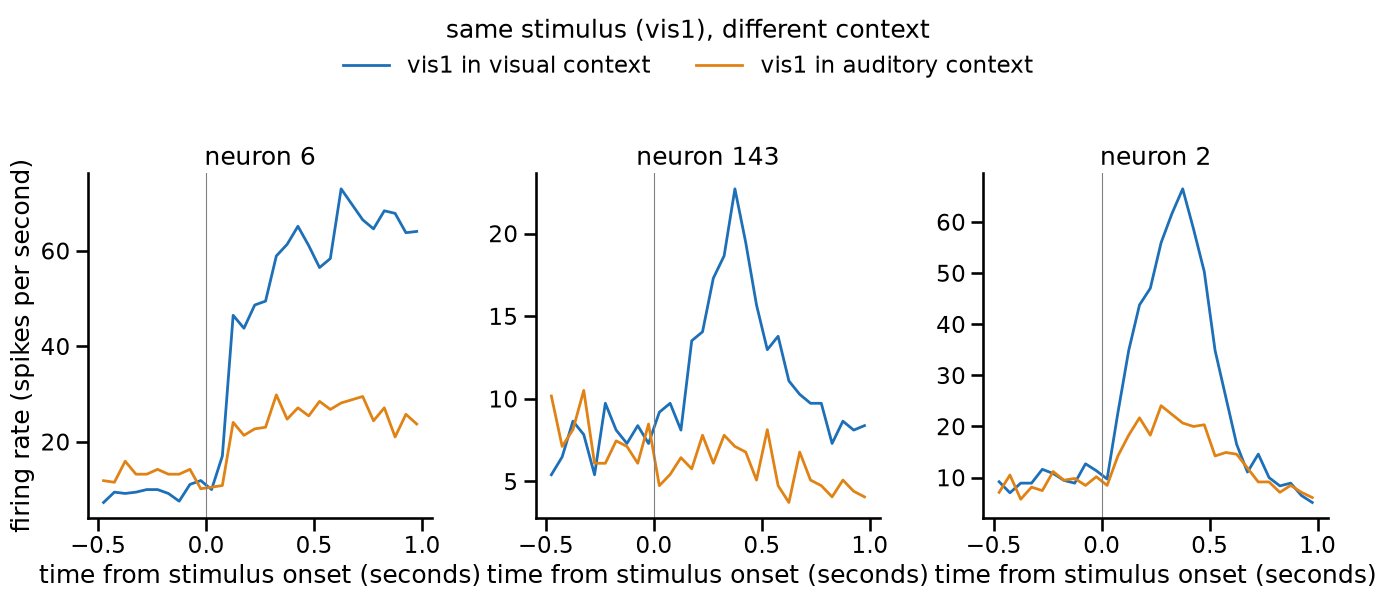

In [40]:
# three 'random' example neurons (hardcoded so the class sees the same ones).
# try changing these!
# three example neurons (hardcoded so everyone sees the same ones to start).
RANDOM_EXAMPLE_INDEX_LIST = VIS_SELECTIVE_INDEX_LIST[:3]   # valid indices for this session

color_context_vis = '#1D6FB8'   # visual context
color_context_aud = '#E08214'   # auditory context

vis1_vis_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'vis'),
    'stim_start_time'].values
vis1_aud_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'aud'),
    'stim_start_time'].values
print('vis1 trials: %d in visual context, %d in auditory context'
      % (len(vis1_vis_time_array), len(vis1_aud_time_array)))

fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for panel_index, neuron_row_index in enumerate(RANDOM_EXAMPLE_INDEX_LIST):
    single_ax = ax[panel_index]
    single_ax.plot(psth_bin_center_array,
                   neuron_psth(neuron_row_index, vis1_vis_time_array),
                   color=color_context_vis, linewidth=2, label='vis1 in visual context')
    single_ax.plot(psth_bin_center_array,
                   neuron_psth(neuron_row_index, vis1_aud_time_array),
                   color=color_context_aud, linewidth=2, label='vis1 in auditory context')
    single_ax.axvline(0, color='0.5', linewidth=0.8)
    single_ax.set_title('neuron %d' % neuron_row_index)
    single_ax.set_xlabel('time from stimulus onset (seconds)')
    sns.despine(ax=single_ax)
ax[0].set_ylabel('firing rate (spikes per second)')
handle_list, label_list = ax[0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='same stimulus (vis1), different context',
           loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
fig.subplots_adjust(top=0.80, wspace=0.3)
plt.show()

### 🏋️‍♂️🏋️‍♂️🏋️‍♂️ Exercise time, together

*Each person at your table: change `RANDOM_EXAMPLE_INDEX_LIST` to three different neuron numbers and re-run. Who found the neuron with the strongest context effect (the biggest gap between the two curves)? Compare across the table.*

### 5.2 Decode vis1 vs vis2 pooling both contexts

Now decode the two stimuli, but let the trials come from both contexts. Each
stimulus now carries extra, context-driven variability.

In [41]:
pooled_trial_mask = trials.stim_name.isin(['vis1', 'vis2'])
pooled_stim_time_array = trials.loc[pooled_trial_mask, 'stim_start_time'].values
pooled_label_array = trials.loc[pooled_trial_mask, 'stim_name'].values
pooled_context_array = trials.loc[pooled_trial_mask, 'rewarded_modality'].values
print('pooled trials: %d (both contexts)' % len(pooled_label_array))

pooled_tensor = np.zeros((n_neurons, len(pooled_stim_time_array),
                          len(decode_bin_edge_array) - 1))
for neuron_row_index in range(n_neurons):
    pooled_tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
        this_structure_units_table.spike_times.values[neuron_row_index],
        pooled_stim_time_array, decode_bin_edge_array)
pooled_count_array = np.sum(pooled_tensor[:, :, window_bin_slice], axis=2).T

x_train, x_test, y_train, y_test, context_train, context_test = train_test_split(
    pooled_count_array, pooled_label_array, pooled_context_array, random_state=0)
pooled_svc = LinearSVC(max_iter=5000)
pooled_svc.fit(x_train, y_train)
pooled_accuracy = pooled_svc.score(x_test, y_test)
print('pooled-context decoder is correct on %.0f%% of held-out trials'
      % (100 * pooled_accuracy))

# cross-validated score (5-fold)
pooled_cv_array = cross_val_score(
    LinearSVC(max_iter=5000), pooled_count_array, pooled_label_array, cv=5)
print('pooled-context cross-validated accuracy: %.0f%% (folds %.0f to %.0f%%)'
      % (100 * pooled_cv_array.mean(),
         100 * pooled_cv_array.min(), 100 * pooled_cv_array.max()))

pooled trials: 253 (both contexts)
pooled-context decoder is correct on 94% of held-out trials
pooled-context cross-validated accuracy: 93% (folds 82 to 98%)


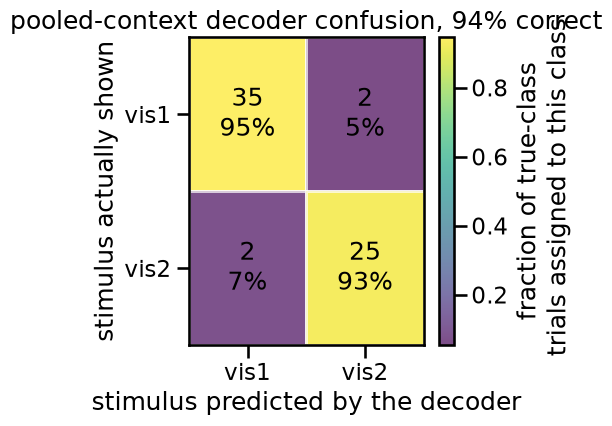

In [42]:
plot_confusion(y_test, pooled_svc.predict(x_test), stim_name_array,
               'pooled-context decoder confusion, %.0f%% correct'
               % (100 * pooled_accuracy))

### 5.3 Where do the mistakes sit?

Color the held-out trials by the context they came from, split correct vs mistake.
If context is the culprit, the errors will not be spread evenly.

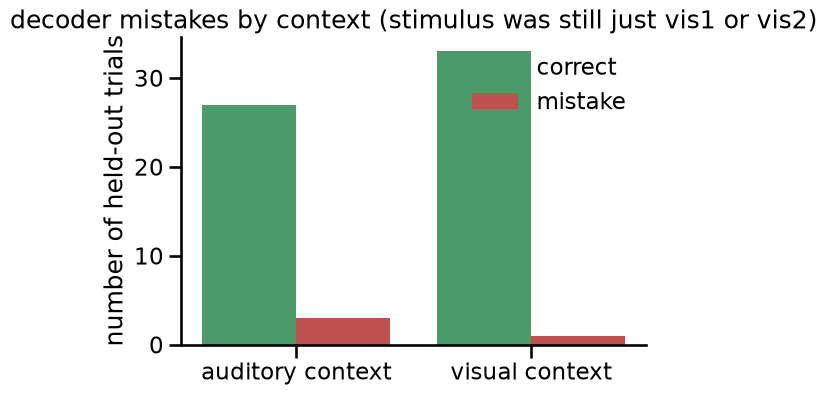

In [43]:
y_test_prediction = pooled_svc.predict(x_test)
is_error_array = y_test_prediction != y_test
context_name_array = np.array(['aud', 'vis'])
correct_count_list = [np.sum(context_test[~is_error_array] == c) for c in context_name_array]
error_count_list = [np.sum(context_test[is_error_array] == c) for c in context_name_array]

fig, ax = plt.subplots(figsize=(6, 4))
x_pos_array = np.arange(len(context_name_array))
ax.bar(x_pos_array - 0.2, correct_count_list, width=0.4, color='#4C9A6A', label='correct')
ax.bar(x_pos_array + 0.2, error_count_list, width=0.4, color='#C0504D', label='mistake')
ax.set_xticks(x_pos_array)
ax.set_xticklabels(['auditory context', 'visual context'])
ax.set_ylabel('number of held-out trials')
ax.set_title('decoder mistakes by context (stimulus was still just vis1 or vis2)')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

### 5.4 How can we improve it? Fix the context

Hold context fixed to visual blocks (the section 3 decode) and compare against the
pooled version.

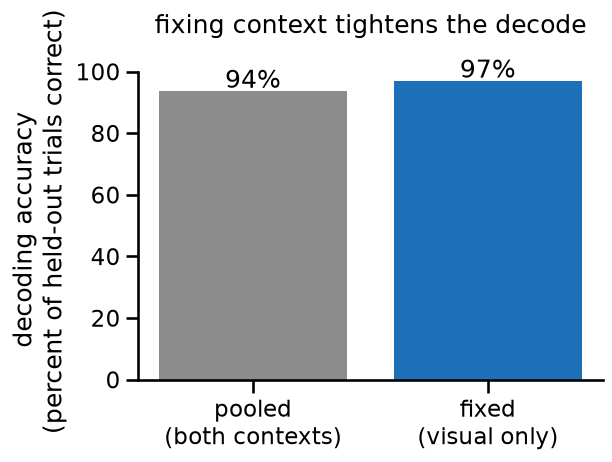

In [44]:
fig, ax = plt.subplots(figsize=(6, 4))
bar_label_list = ['pooled\n(both contexts)', 'fixed\n(visual only)']
bar_value_list = [100 * pooled_accuracy, 100 * population_accuracy]
ax.bar(bar_label_list, bar_value_list, color=['#8C8C8C', '#1D6FB8'])
for x_pos, value in enumerate(bar_value_list):
    ax.text(x_pos, value + 1, '%.0f%%' % value, ha='center')
ax.set_ylabel('decoding accuracy \n (percent of held-out trials correct)')
ax.set_ylim(0, 100)
ax.set_title('fixing context tightens the decode\n')
sns.despine(ax=ax)
plt.show()

### 5.5 Thinking question

Fixing context improved the decoder. **Why?**

The stimulus was the same either way, vis1 or vis2. What did pooling the two
contexts add that made the two stimulus clouds harder to separate? And what does
that tell you about what MOs represents, beyond the stimulus itself?

## 6. Which neurons carry the decode? (feature importance)

The fitted SVM gives every neuron a **weight**. That weight is the neuron's **feature importance**: how much it pushes the decision toward one stimulus or the other. Usually a few neurons do most of the work.

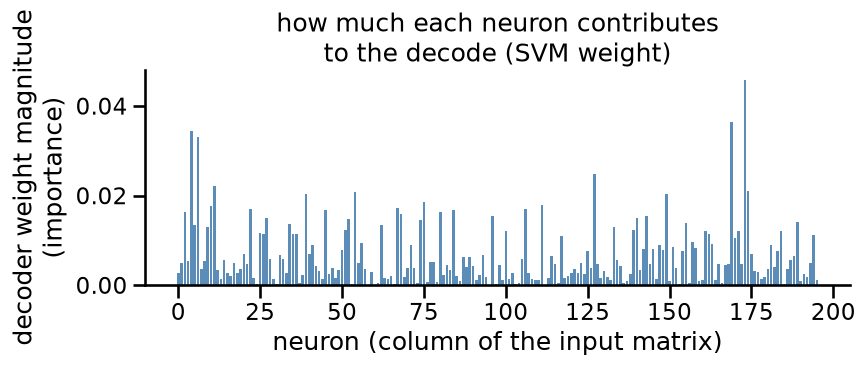

In [45]:
# absolute SVM weight per neuron = how much it contributes, regardless of direction
weight_array = np.abs(population_svc.coef_.ravel())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(len(weight_array)), weight_array, color='#5B8DB8')
ax.set_xlabel('neuron (column of the input matrix)')
ax.set_ylabel('decoder weight magnitude\n(importance)')
ax.set_title('how much each neuron contributes\nto the decode (SVM weight)')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

🧠 **THINK!**

*Would the same neurons carry the decode for the two sounds (sound1 vs sound2)? Predict first, then, if you have time, test it by re-running the population decode on the auditory stimuli and comparing the weights.*

# Train on one context and test on the other

Here is the deeper question the original notebook ended on. If MOs really carries a stimulus code, a decoder trained in one context should still work in the other.

We train the vis1 vs vis2 decoder on **auditory-context** trials, then test it on **visual-context** trials, and vice versa. If accuracy holds up, the stimulus code generalizes across context. If it drops, context is entangled with the stimulus representation.

Build context-specific matrices, then cross-decode.

In [46]:
def population_matrix_for_mask(trial_mask):
    stim_time_array = trials.loc[trial_mask, 'stim_start_time'].values
    label_array = trials.loc[trial_mask, 'stim_name'].values
    tensor = np.zeros((n_neurons, len(stim_time_array), len(decode_bin_edge_array) - 1))
    for neuron_row_index in range(n_neurons):
        tensor[neuron_row_index] = get_binned_triggered_spike_counts_fast(
            this_structure_units_table.spike_times.values[neuron_row_index],
            stim_time_array, decode_bin_edge_array)
    count_array = np.sum(tensor[:, :, window_bin_slice], axis=2).T
    return count_array, label_array


vis_mask = trials.stim_name.isin(['vis1', 'vis2']) & (trials.rewarded_modality == 'vis')
aud_mask = trials.stim_name.isin(['vis1', 'vis2']) & (trials.rewarded_modality == 'aud')

x_vis_context, y_vis_context = population_matrix_for_mask(vis_mask)
x_aud_context, y_aud_context = population_matrix_for_mask(aud_mask)

# train on auditory context, test on visual context
svc_train_aud = LinearSVC(max_iter=5000).fit(x_aud_context, y_aud_context)
acc_aud_to_vis = svc_train_aud.score(x_vis_context, y_vis_context)

# train on visual context, test on auditory context
svc_train_vis = LinearSVC(max_iter=5000).fit(x_vis_context, y_vis_context)
acc_vis_to_aud = svc_train_vis.score(x_aud_context, y_aud_context)

print('train auditory context, test visual context: %.0f%% correct'
      % (100 * acc_aud_to_vis))
print('train visual context, test auditory context: %.0f%% correct'
      % (100 * acc_vis_to_aud))

train auditory context, test visual context: 79% correct
train visual context, test auditory context: 65% correct


Compare the cross-context accuracies to the within-context decoder from section 3.

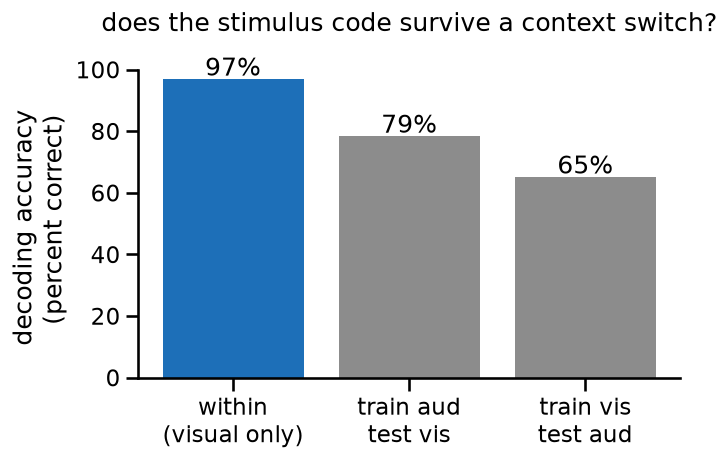

In [47]:
fig, ax = plt.subplots(figsize=(7, 4))
bar_label_list = ['within\n(visual only)', 'train aud\ntest vis', 'train vis\ntest aud']
bar_value_list = [100 * population_accuracy, 100 * acc_aud_to_vis, 100 * acc_vis_to_aud]
ax.bar(bar_label_list, bar_value_list, color=['#1D6FB8', '#8C8C8C', '#8C8C8C'])
for x_pos, value in enumerate(bar_value_list):
    ax.text(x_pos, value + 1, '%.0f%%' % value, ha='center')
ax.set_ylabel('decoding accuracy \n (percent correct)')
ax.set_ylim(0, 100)
ax.set_title('does the stimulus code survive a context switch?\n')
sns.despine(ax=ax)
plt.show()

## 7. Which brain areas carry the stimulus?

So far everything used MOs. Do other areas decode vis1 vs vis2 as well? We rerun
the population decoder in several areas and compare. This is the final figure of
the day.

MOs: 98% (196 units)
skipping VISp, only 0 good units
skipping VISl, only 0 good units
skipping VISam, only 0 good units
ACAd: 81% (6 units)
CP: 99% (130 units)


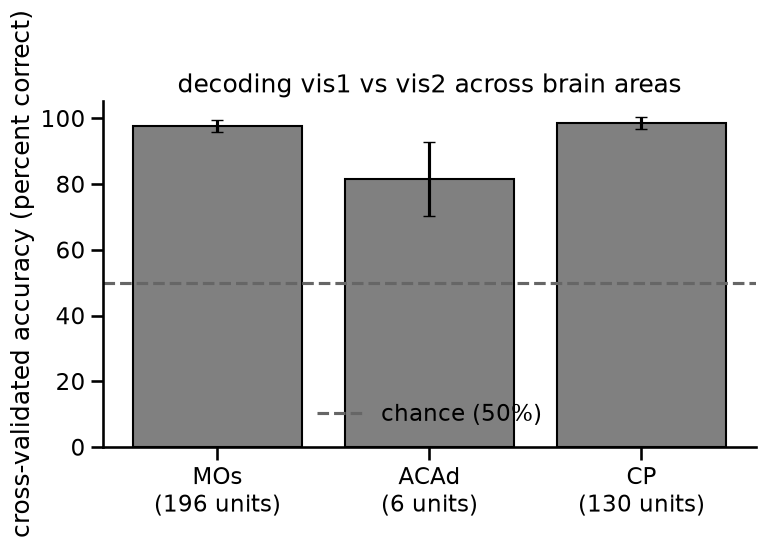

In [49]:
# decode vis1 vs vis2 in several brain areas and compare accuracy
area_name_list = ['MOs', 'VISp', 'VISl', 'VISam', 'ACAd', 'CP']

decode_trial_mask = (trials.stim_name.isin(['vis1', 'vis2']) &
                     (trials.rewarded_modality == 'vis'))
area_stim_time_array = trials.loc[decode_trial_mask, 'stim_start_time'].values
area_label_array = trials.loc[decode_trial_mask, 'stim_name'].values

area_mean_accuracy_list = []
area_std_accuracy_list = []
kept_area_name_list = []
for area_name in area_name_list:
    area_units_table = good_units[good_units.structure == area_name]
    if len(area_units_table) < 5:                    # skip areas with too few neurons
        print('skipping %s, only %d good units' % (area_name, len(area_units_table)))
        continue
    area_count_array = np.zeros((len(area_stim_time_array), len(area_units_table)))
    for column_index, spike_time_array in enumerate(area_units_table.spike_times.values):
        area_count_array[:, column_index] = get_binned_triggered_spike_counts_fast(
            spike_time_array, area_stim_time_array, np.array([0.0, 0.5])).ravel()
    area_cv_array = cross_val_score(
        LinearSVC(max_iter=5000), area_count_array, area_label_array, cv=5)
    area_mean_accuracy_list.append(area_cv_array.mean())
    area_std_accuracy_list.append(area_cv_array.std())
    kept_area_name_list.append('%s\n(%d units)' % (area_name, len(area_units_table)))
    print('%s: %.0f%% (%d units)'
          % (area_name, 100 * area_cv_array.mean(), len(area_units_table)))

fig, ax = plt.subplots(figsize=(8, 5))
x_position_array = np.arange(len(kept_area_name_list))
ax.bar(x_position_array, 100 * np.array(area_mean_accuracy_list),
       yerr=100 * np.array(area_std_accuracy_list), color='0.5',
       edgecolor='k', capsize=4)
ax.axhline(50, linestyle='--', color='0.4', label='chance (50%)')
ax.set_xticks(x_position_array)
ax.set_xticklabels(kept_area_name_list)
ax.set_ylabel('cross-validated accuracy (percent correct)')
ax.set_title('decoding vis1 vs vis2 across brain areas')
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### If you want to keep exploring (evening / homework)

Some directions to take this further:

1. Decode **context itself** from baseline spikes (before the stimulus). Can you tell which block the mouse is in before anything happens?
2. Decode across **more brain areas** and rank them by how well they decode the stimulus.
3. Ask how decoding depends on the number of neurons: subsample the population and plot accuracy vs number of neurons.
4. Split trials by the mouse's **behavior** (hit vs miss) and see whether the stimulus is easier to decode when the mouse responded.
5. Look at **catch trials** (no stimulus). What does the decoder do when there is nothing to decode?
6. Decode **all four stimuli at once** (vis1, vis2, sound1, sound2) instead of a pair. How does a 4-way confusion matrix look, and which stimuli get confused?

## Recap

1. Single neurons carry some stimulus information, visible by eye.
2. An SVM finds the widest-margin boundary between two classes of trials.
3. The population decodes far better than any single neuron.
4. The decoder's mistakes are not random. Context leaks into the neural response,
   and fixing context makes the stimulus easier to read out.

MOs is not only relaying the stimulus, it is also carrying context. What the brain
does with that is the interesting part.